In [1]:
#import user modules
#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

import sys
my_path = "../../Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

from fit_funcs import *
import costfun.costfun as cost
import utils.figures as fig_help
from RandomMatrixTheory import goe, gue
from Quad_tools import *
import entropy as ent

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)

import itertools
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}

%matplotlib inline
colors_ls = (list(mcolors.TABLEAU_COLORS)[:200])
colors_ls_cyc = itertools.cycle(colors_ls)

markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   


# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import gamma as Gamma
from scipy.special import lambertw
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
 
# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists

DIM = 3
modello = 'Anderson'


def base_dir(model, d, ensemble = 'GOE', BC = 0):
    """
    Base directory for input model for d-dimension
    """
    dirx = f"../results/{model}/" + (ensemble + f"/" if model == 'PLRB' or model == 'RP' or model == 'SYK2' else  f"dim={d}/") + ( '' if model == 'RP' or model == 'SYK2' else (f"PBC/" if BC else f"OBC/") )
    return dirx

print(base_dir(modello, DIM))

%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}

/Users/rafal.swietek/Projects/CODES/QHamSolver/Quadratic/Jupyter_Python
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../Python/
../results/Anderson/dim=3/OBC/


In [2]:

def borels_triangle(n, k):
    return 1 / n * binom(2*n, n-k-1) * binom(n+k-1, k)

def QC_terms(f, n):
    y = 0
    for k in range(0, n):
        # print(n, k)
        y += (-1)**k * borels_triangle(n, k) * f**k
    return f**n * y
    # return f**n * np.sum( [(-1)**k * borels_triangle(n, k) ** f**k for k in range(n)] )

def correction(n=4):
    return np.log(2) - np.sum( [1 / (2 * k * (2 * k - 1)) for k in range(1, n)] )

def gdeg(x, n):    
    if n == 1:      return 2/(1+x)
    elif n == 2:    return 4*(5+x) / ( (1+x)*(2+x)*(3+x) )
    elif n == 3:    return 8*(x**2 + 15*x + 74) / ( (1+x)*(2+x)*(3+x)*(4+x)*(5+x) )
    elif n == 4:    return 16*(x**3 + 30*x**2 + 371*x + 2118) / ( (1+x)*(2+x)*(3+x)*(4+x)*(5+x)*(6+x)*(7+x) )
    else:           return (2/(1+x))**n

def leading_QC_terms(f, x, n=4):
    res = QC_terms(f, n=1)/2 * gdeg(x, 1)
    if n >= 2:  res += QC_terms(f, n=2) / 12 * gdeg(x,2)
    if n >= 3:  res += QC_terms(f, n=3) / 30 * gdeg(x,3)
    if n >= 4:  res += QC_terms(f, n=4) / 56 * gdeg(x,4)
    # ..... other terms
    return res

def QC_upper_bound(f, x, n):
    return 1 - leading_QC_terms(f, x, n=n) / (np.log(2))

def QC_lower_bound(f, x, n):
    return 1 - (leading_QC_terms(f=f, x=x, n=n) + QC_terms(f=f, n=n) * correction(n=n+1) * gdeg(x=x, n=n)) / (np.log(2))

def QCQ_trace_series(f, x):
    return 1 + (1-2*f+x)*np.log(1-2*f/(1+x)) / (2*f)

def s_QCQ(f, x):
    return 1 - (QCQ_trace_series(f, x)) / np.log(2)

# def NonGaussianity(x, n=4):
#     y = 0
#     for k in range(1, n+1):
#         y += Gamma(2*k - 1) * Gamma(k + x) / ( Gamma(k + 1) * Gamma(2*k + x) )
#     return 1 - y / np.log(2)
#     # return f**n * np.sum( [(-1)**k * borels_triangle(n, k) ** f**k for k in range(n)] )

def NonGaussianity(x, n=4, ens=1):
    y = 0
    if ens:
        for k in range(1, n+1):
            val = Gamma(2*k - 1) / Gamma(k + 1)
            for s in range(k, 2*k):
                # print(k, s)
                val = val / (s + x)
            y += val
        return 1 - y / np.log(2)
    else:
        y = 3 / 2 / (x + 2)
        if n > 1: y += 3/12 * (9*x + 26) / ( (x+2)*(x+4)*(x+6) )
        if n > 2: y += 135/30 * (3*x**2 + 26*x + 48) / ( (x+2)*(x+4)*(x+6)*(x+8)*(x+10) )
        if n > 3: y += 9/56 * (945*x**3 + 1701*x**2+11705*x+210874) / ( (x+2)*(x+4)*(x+6)*(x+8)*(x+10)*(x+12)*(x+14) )
        return 1 - y / np.log(2)

# def s_QCQ(f, x):
#     y = 0
#     for n in range(3):
#         y += 1 / (n + x)
#     return 1 - y / np.log(2)


In [3]:

def FF_terms(f, x, n):
    # if n == 1:  return f
    # if n == 2:  return 8/3 * f**2 - 2 * f**3
    # if n == 3:  return 11 * f**3 - 24 * f**4 + 16 * f**5
    # if n == 4:  
    #     res = 908/15 * f**4 - 1296/5 * f**5 + 27320/63 * f**6 - 272 * f**7
    #     if f >= 1/4 and f < 1/3: res += 8192/315*f**6 - 2048/45*f**5 + 512/15*f**4 - 128/9*f**3 + 32/9*f**2 - 8/15*f + 2/45 - 1/(630*f)
    #     if f >= 1/3 and f <= 1/2: res += 12136/63*f**6 - 13712/45*f**5 + 556/3*f**4 - 452/9*f**3 + 32/9*f**2 + 16/15*f - 2/9 + 1/(90*f)
    #     return res
    # else:       return 0
    # if n == 1:  return 2/(1+x) * f
    # if n == 2:  return 8/3 * 4*(5+x) / ( (1+x)*(2+x)*(3+x) ) * f**2 + 2 * 12/( (2+x)*(3+x) ) * f**3
    # if n == 3:  return (11 * 8*(x**2 + 15*x + 74) * f**3 - 24 * 24*(x + 14)*(x + 1) * f**4 + 16 * 120*(x+1)*(x+2) * f**5 ) / ( (1+x)*(2+x)*(3+x)*(4+x)*(5+x) )
    # if n == 4:  
    #     res = 908/15  * 16*(x**3 + 30*x**2 + 371*x + 2118)    / ( (1+x)*(2+x)*(3+x)*(4+x)*(5+x)*(x+6)*(x+7) ) * f**4\
    #                 -   1296/5  * 24*(x + 9)                            / ( (1+x)*(3+x)*(4+x)*(5+x) )                   * f**5\
    #                 +   5816/63 * 144*(x**3 + 22*x**2 + 123*x + 134)    / ( (1+x)*(2+x)*(3+x)*(4+x)*(5+x)*(x+6)*(x+7) ) * f**6\
    #                 +   1024/3  * 240*(x + 13)                          / ( (1+x)*(4+x)*(5+x)*(x+6)*(x+7) )             * f**6\
    #                 -   272     * 1680                                  / ( (4+x)*(5+x)*(x+6)*(x+7) )                   * f**7
    #     if f >= 1/4 and f < 1/3:    res += (8192/315*f**6 - 2048/45*f**5 + 512/15*f**4 - 128/9*f**3 + 32/9*f**2 - 8/15*f + 2/45 - 1/(630*f)) * 144*(x**3 + 22*x**2 + 123*x + 134)   / ( (1+x)*(2+x)*(3+x)*(4+x)*(5+x)*(x+6)*(x+7) ) 
    #     if f >= 1/3 and f <= 1/2:   res += (12136/63*f**6 - 13712/45*f**5 + 556/3*f**4 - 452/9*f**3 + 32/9*f**2 + 16/15*f - 2/9 + 1/(90*f)) * 144*(x**3 + 22*x**2 + 123*x + 134)    / ( (1+x)*(2+x)*(3+x)*(4+x)*(5+x)*(x+6)*(x+7) )
    #     return res
    # else:       return 0

    if n == 1:  return 2/(1+x) * f
    if n == 2:  return (8/3 * f**2 - 3*f**3) * 4*(5+x) / ( (1+x)*(2+x)*(3+x) ) + 12/( (2+x)*(3+x) ) * f**3
    if n == 3:  return ( (11*f**3 - 36*f**4 + 30*f**5) * 8*(x**2 + 15*x + 74) + (12*f**4 - 15*f**5) * 24*(x + 14)*(x + 1) + f**5 * 120*(x+1)*(x+2)) / ( (1+x)*(2+x)*(3+x)*(4+x)*(5+x) )
    if n == 4:  
        res = 908/15  * 16*(x**3 + 30*x**2 + 371*x + 2118)    / ( (1+x)*(2+x)*(3+x)*(4+x)*(5+x)*(x+6)*(x+7) ) * f**4\
                    -   1296/5  * 24*(x + 9)                            / ( (1+x)*(3+x)*(4+x)*(5+x) )                   * f**5\
                    +   5816/63 * 144*(x**3 + 22*x**2 + 123*x + 134)    / ( (1+x)*(2+x)*(3+x)*(4+x)*(5+x)*(x+6)*(x+7) ) * f**6\
                    +   1024/3  * 240*(x + 13)                          / ( (1+x)*(4+x)*(5+x)*(x+6)*(x+7) )             * f**6\
                    -   272     * 1680                                  / ( (4+x)*(5+x)*(x+6)*(x+7) )                   * f**7
        if f >= 1/4 and f < 1/3:    res += (8192/315*f**6 - 2048/45*f**5 + 512/15*f**4 - 128/9*f**3 + 32/9*f**2 - 8/15*f + 2/45 - 1/(630*f)) * 144*(x**3 + 22*x**2 + 123*x + 134)   / ( (1+x)*(2+x)*(3+x)*(4+x)*(5+x)*(x+6)*(x+7) ) 
        if f >= 1/3 and f <= 1/2:   res += (12136/63*f**6 - 13712/45*f**5 + 556/3*f**4 - 452/9*f**3 + 32/9*f**2 + 16/15*f - 2/9 + 1/(90*f)) * 144*(x**3 + 22*x**2 + 123*x + 134)    / ( (1+x)*(2+x)*(3+x)*(4+x)*(5+x)*(x+6)*(x+7) )
        return res
    else:       return 0

    # if n == 1:  return 2/(1+x) * f
    # if n == 2:  return 8/3 * (2 / (1+x))**2 * f**2 - 2 * 12*(x**2 + x + 2)/( (1+x)**2*(2+x)*(3+x) ) * f**3 
    # if n == 3:  return (11 * (2/(1+x))**3 * f**3 - 24 * 24*(x**2 + x + 2)/( (1+x)**3*(2+x)*(3+x) ) * f**4 + 16 * 120*(x**4 + 2*x**3 + 47*x**2 - 2*x - 24)/( (1+x)**3*(2+x)*(3+x)*(4+x)*(5+x) )  * f**5 )
    # if n == 4:  
    #     res = 908/15 * (2/(1+x))**4                                                                                                                                                     * f**4\
    #                 -   1296/5  * 48*(x**2 + x + 2)                                                                                   /( (1+x)**4*(2+x)*(3+x) )                         * f**5\
    #                 +   5816/63 * 144*(x**2 + x + 2)**2                                                                               /( (1+x)**2*(2+x)*(3+x) )**2                      * f**6\
    #                 +   1024/3  * 240*(x**4 + 2*x**3 + 47*x**2 - 2*x - 24)                                                            /( (1+x)**4*(2+x)*(3+x)*(4+x)*(5+x) )             * f**6\
    #                 -   272     * 1680*(x**8 + 8*x**7 + 196*x**6 - 2122*x**5 - 15713*x**4 - 22438*x**3 + 10188*x**2 + 24984*x + 7200) / ( (1+x)**4*(2+x)**2*(3+x)**2*(4+x)*(5+x)*(x+6)*(x+7) )   * f**7
    #     # if f >= 1/4 and f < 1/3:    res += (8192/315*f**6 - 2048/45*f**5 + 512/15*f**4 - 128/9*f**3 + 32/9*f**2 - 8/15*f + 2/45 - 1/(630*f)) * 144*(x**2 + x + 2)**2 /( (1+x)**2*(2+x)*(3+x) )**2
    #     # if f >= 1/3 and f <= 1/2:   res += (12136/63*f**6 - 13712/45*f**5 + 556/3*f**4 - 452/9*f**3 + 32/9*f**2 + 16/15*f - 2/9 + 1/(90*f)) * 144*(x**2 + x + 2)**2 /( (1+x)**2*(2+x)*(3+x) )**2
    #     return res
    # else:       return 0

def correction(n=4):
    return np.log(2) - np.sum( [1 / (2 * k * (2 * k - 1)) for k in range(1, n)] )

def leading_FF_terms(f, x, n=4):

    res = FF_terms(f=f, x=x, n=1) / 2
    if n >= 2:  res += FF_terms(f=f, x=x, n=2) / 12
    if n >= 3:  res += FF_terms(f=f, x=x, n=3) / 30
    if n >= 4:  res += FF_terms(f=f, x=x, n=4) / 56
    return res

def FF_upper_bound(f, x, n):
    return 1 - leading_FF_terms(f, x, n=n) / (np.log(2))

def FF_lower_bound(f, x, n):
    return 1 - (leading_FF_terms(f=f, x=x, n=n) + FF_terms(f=f, x=x, n=n) * correction(n=n+1)) / (np.log(2))



In [4]:
def g2n(x, n):
    return Gamma(x+1) * Gamma(2*n+1) / Gamma(2*n + x)

# Ensemble choosing
# ens = 0 --> GOE
# ens = 1 --> GUE

def A2(VA, f, x, ens = 1):
    term = VA * f# + (f*(1-f))
    corr = 2 / (1+x) if ens else 3 / (2+x)
    return term * corr
    # return VA * f# * 2 * x / (1+x)
    # return VA * f * g2n(x, 1)

def A22(VA, f, x, ens = 1):
    corr = 4*(5+x) / ( (1+x)*(2+x)*(3+x) ) if ens else 3*(3*x + 32) / ( (2+x)*(4+x)*(6+x) )
    return 2*VA * (f**2 - f**3) * corr
    # return 2*VA * (f**2 - f**3)# * 4 * x**2 / (1+x)**2
    # return 2*VA * (f**2 - f**3) * g2n(x, 1)**2

def A4(VA, f, x, ens = 1):
    corr = 12 / ( (2+x)*(3+x) ) if ens else 3*(9*x + 26) / ( (2+x)*(4+x)*(6+x) )
    return VA * f**3 * corr
    # return VA * f**3# * 12*x*(-4 + 2*x + 5*x**2 + x**3) / ( (1+x)**2 * (2+x)*(3+x) )
    # return VA * f**3 * g2n(x, 2)

def A222(VA, f, x, ens = 1):
    corr = 8*(74 + 15*x + x**2) / ( (1+x)*(2+x)*(3+x)*(4+x)*(5+x) ) if ens else 27*(x**2 + 32*x + 352)  / ( (2+x)*(4+x)*(6+x)*(8+x)*(10+x) )
    return VA * (5*f**3 - 12*f**4 + 7*f**5) * corr
    # return VA * (5*f**3 - 12*f**4 + 7*f**5)# * 8 * x**3 / (1+x)**3
    # return VA * (5*f**3 - 12*f**4 + 7*f**5) * g2n(x, 1)**3

def A24(VA, f, x, ens = 1):
    corr = 24*(9+x) / ( (1+x)*(3+x)*(4+x)*(5+x) ) if ens else 9 * (9*x**2 + 218*x + 928) / ( (2+x)*(4+x)*(6+x)*(8+x)*(10+x) )
    return 6*VA * (f**4 - f**5) * corr
    # return 6*VA * (f**4 - f**5)# * 24 * x**2 * (-4 + 2*x + 5*x**2 + x**3) / ( (1+x)**3 * (2+x)*(3+x) )
    # return 6*VA * (f**4 - f**5) * g2n(x, 1)*g2n(x, 2)

def A6(VA, f, x, ens = 1):
    corr = 120 / ( (3+x)*(4+x)*(5+x) ) if ens else 45 * (9*x**2 + 78*x + 144)/ ( (2+x)*(4+x)*(6+x)*(8+x)*(10+x) )
    return VA * f**5 * corr
    # return VA * f**5# * 120 * (x-1) * x * (-90 - 30*x + 108*x**2 + 74*x**3+15*x**4+x**5) / ( (1+x)**3 * (2+x)*(3+x) * (4+x)*(5+x) )
    # return VA * f**5 * g2n(x, 3)

def Trace2n(VA, f, x, n=3, ens=1):
    if n == 1: return A2(VA, f, x,ens)
    elif n == 2: return (A22(VA, f, x,ens) + A4(VA, f, x,ens))
    elif n == 3: return (A222(VA, f, x,ens) + A24(VA, f, x,ens) + A6(VA, f, x,ens))
    elif n == 4: return (A222(VA, f, x,ens) + A24(VA, f, x,ens) + A6(VA, f, x,ens))
    else:
        return 0
    

def leading_QC_terms(f, x, n=4, ens=1):
    res = Trace2n(VA=1, f=f, x=x, n=1, ens=ens) / 2
    if n >= 2:  res += Trace2n(VA=1, f=f, x=x, n=2, ens=ens) / 12
    if n >= 3:  res += Trace2n(VA=1, f=f, x=x, n=3, ens=ens) / 30
    if n >= 4:  res += Trace2n(VA=1, f=f, x=x, n=4, ens=ens) / 56
    # ..... other terms
    return res

def QC_upper_bound(f, x, n, ens=1):
    return 1 - leading_QC_terms(f, x, n=n, ens=ens) / (np.log(2))

def QC_lower_bound(f, x, n, ens=1):
    return 1 - (leading_QC_terms(f=f, x=x, n=n, ens=ens) + Trace2n(VA=1, f=f, x=x, n=n, ens=ens) * correction(n=n+1)) / (np.log(2))


## INITIAL TESTS

-0.40443978243306855


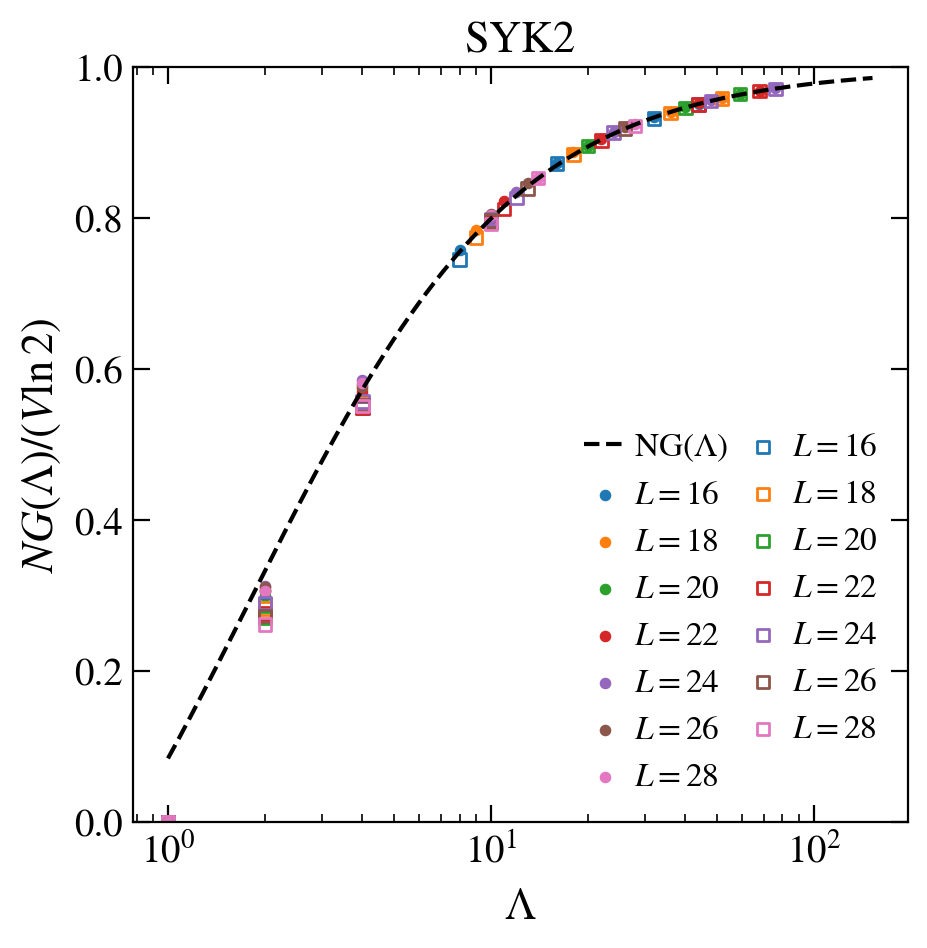

In [1074]:
L = 100
w = 1
J = 1
g = 0.618



fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)
# fig, axis_flu

op=1

prefix = base_dir(model='SYK2', d=1) + 'Entropy/Degeneracy/'
# if op == 2:   prefix += "AllStates/"
# else:         prefix += "RandomChoice/"
prefix += "RandomChoice/"
if op == 1:   prefix += "SameHamiltonian/"
else:         prefix += "DifferentHamiltonian/"
# ax_inset = fig_help.add_subplot_axes(axis, fig, [0.5, 0.5, 0.46, 0.46])

colors_ls_cyc = itertools.cycle(colors_ls)
# gams = np.arange(1,201, 1)

# sizes = np.array([100, 200, 500, 1000])

sizes = np.arange(16, 29, 2)

subsize_idx = -1

names = [r"$f=\frac{1}{6}$", r"$f=\frac{1}{4}$", r"$f=\frac{1}{2}$", r"$f=\frac{1}{2}$"]
fracs = [1/6, 1/4, 1/2, 1/2]

Gmax = 0

syms = ['o', 's']

for op in [0, 1]:
    prefix = base_dir(model='SYK2', d=1) + 'Entropy/Degeneracy/'
    prefix += "RandomChoice/"
    if op == 1:   prefix += "SameHamiltonian/"
    else:         prefix += "DifferentHamiltonian/"
    colors_ls_cyc = itertools.cycle(colors_ls)
    for id_L, L in enumerate(sizes):
        V = L
        LA = fracs[subsize_idx] * L
        col = next(colors_ls_cyc)

        name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
        # print(name)
        if exists(name):
            with h5py.File(name, "r") as file:
                gams = np.array(file.get('Gammas'))
                if max(gams) > Gmax: Gmax = max(gams)
                S = np.array(file.get('Non-Gaussianity')) / (L * np.log(2))
                # S = np.mean(np.array(file.get('entropy_corr_mat')), axis=0) / (L//2 * np.log(2))
                axis.scatter(gams, S, s=10 + 10*op, color=col, label=r"$L=%d$"%(L), marker=syms[op], facecolor='None' if op else col)
        else:
            print(name)
        # ax_inset.plot(4 * w_vals, ydata, marker='o', markersize=4, label=r"$L=%d$"%(L))
        # axis.axhline(y = 1 - 1. / (V*np.log(2)), color=col, ls='--')


gams = np.linspace(1, 2*Gmax, 100000)
# axis.plot(gams, s_QCQ(1/2, gams), ls='--', color='k', label=r'$s_{QCQ}(\Gamma,1/2)$')
# axis.plot(gams, s_QCQ(1, gams), ls='--', color='k', label=r'${\rm NG}(\Gamma)$')
axis.plot(gams, NonGaussianity(gams, n=4, ens=0), ls='--', color='k', label=r'${\rm NG}(\Lambda)$')
# axis.plot(gams, s_QCQ(1/4, gams), ls='--', color='red', label=r'$s_{QCQ}(\Gamma,1/4)$')
# axis.plot(gams, s_QCQ(1/6, gams), ls='--', color='blue', label=r'$s_{QCQ}(\Gamma,1/6)$')
print(s_QCQ(1, 1.01))
# axis.annotate(r"$f=\frac{1}{2}$", xy=(1.3, 0.55), fontsize=14, rotation=0)
# axis.annotate(r"$f=\frac{1}{4}$", xy=(1.3, 0.8), fontsize=14, rotation=0)
# axis.annotate(r"$f=\frac{1}{6}$", xy=(1.3, 0.93), fontsize=14, rotation=0)

fig_help.set_plot_elements(axis, ylabel=r"$NG(\Lambda) / (V\ln{2})$", xlabel=r"$\Lambda$", font_size=14, set_legend=True, ylim=(0, 1.0), xscale='log', yscale='linear')
axis.legend(loc = 'lower right', columnspacing=0.4, frameon=False, fontsize=12, ncol=2,handletextpad=0.25, handlelength = 1.25)


axis.set_title(r"SYK$2$", fontsize=16)
# fig_help.set_plot_elements(ax_inset, ylabel=r"${\bar{S}_A} / \ln2$", xlabel=r"$W$", font_size=14, set_legend=False, xlim=(8.0, 25.0), ylim=(0.7, 1.0))

fig.subplots_adjust(wspace = 0.3, hspace=0.05)


../results/SYK2/GOE/Entropy/Degeneracy/RandomChoice/SameHamiltonian/_L=32,J=1.hdf5


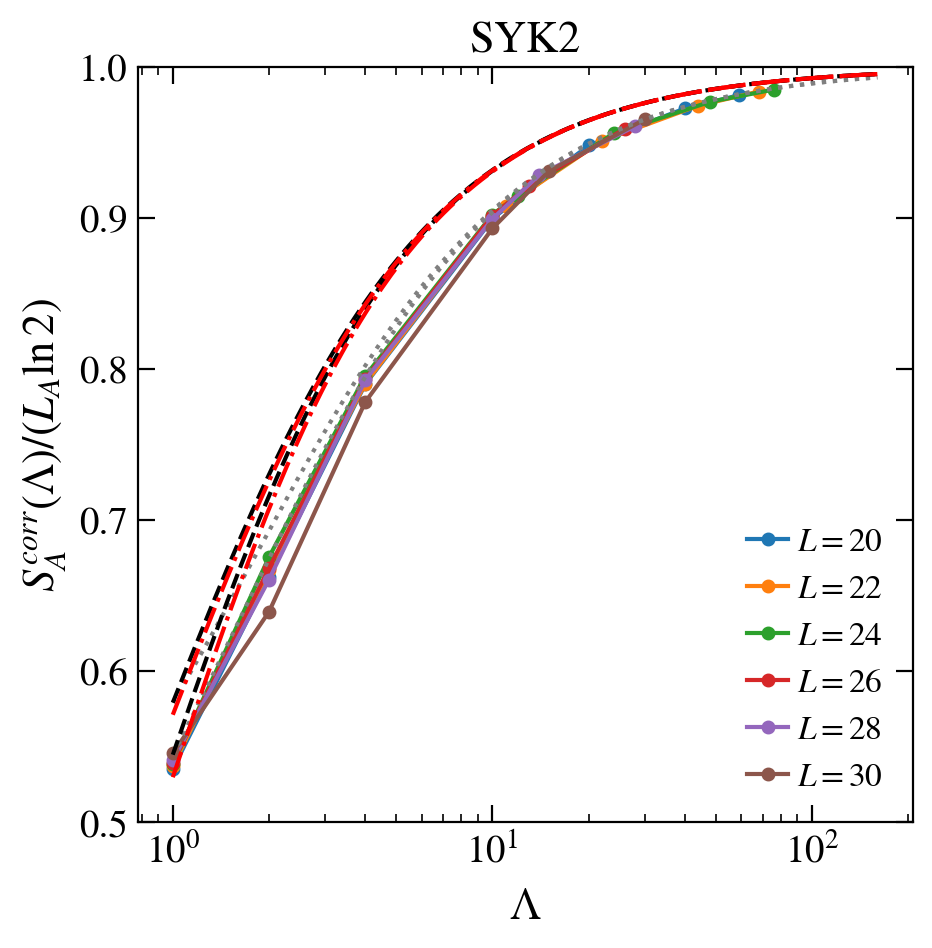

In [6]:
L = 100
w = 1
J = 1
g = 0.618



fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)
# fig, axis_flu

op=1

prefix = base_dir(model='SYK2', d=1) + 'Entropy/Degeneracy/'
# if op == 2:   prefix += "AllStates/"
# else:         prefix += "RandomChoice/"
prefix += "RandomChoice/"
if op == 1:   prefix += "SameHamiltonian/"
else:         prefix += "DifferentHamiltonian/"
# ax_inset = fig_help.add_subplot_axes(axis, fig, [0.5, 0.5, 0.46, 0.46])

colors_ls_cyc = itertools.cycle(colors_ls)
# gams = np.arange(1,201, 1)

# sizes = np.array([100, 200, 500, 1000])

sizes = np.arange(20, 33, 2)

subsize_idx = -1

names = [r"$f=\frac{1}{6}$", r"$f=\frac{1}{4}$", r"$f=\frac{1}{2}$", r"$f=\frac{1}{2}$"]
fracs = [1/4, 1/3, 1/2]

for subsize_idx in [2]:
    colors_ls_cyc = itertools.cycle(colors_ls)
    for id_L, L in enumerate(sizes):
        V = L
        LA = int( fracs[subsize_idx] * L )
        col = next(colors_ls_cyc)

        name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
        # print(name)
        if exists(name):
            with h5py.File(name, "r") as file:
                gams = np.array(file.get('Gammas'))
                S = np.array(file.get('entropy_corr_mat'))
                S = S[LA-1] / (LA * np.log(2))
                if subsize_idx == 2:    axis.plot(gams, S, marker='o', markersize=4, color=col, label=r"$L=%d$"%(L))
                else:                   axis.plot(gams, S, marker='s', markersize=4, color=col, markerfacecolor='None')
        else:
            print(name)
        # ax_inset.plot(4 * w_vals, ydata, marker='o', markersize=4, label=r"$L=%d$"%(L))
        # axis.axhline(y = 1 - 1. / (V*np.log(2)), color=col, ls='--')


gams = np.linspace(1, 5*max(sizes), 1000)
# axis.plot(gams, QC_lower_bound(f=1/2, x=gams, n=1), ls='-', color='gray')
# axis.plot(gams, s_QCQ(1/2, gams), ls='--', color='k', label=r'$s_{QCQ}(\Gamma,1/2)$')
# axis.plot(gams, QC_lower_bound(f=1/4, x=gams, n=1), ls='-', color='gray')
# axis.plot(gams, s_QCQ(1/4, gams), ls='--', color='red', label=r'$s_{QCQ}(\Gamma,1/4)$')
# axis.plot(gams, s_QCQ(1/6, gams), ls='--', color='blue', label=r'$s_{QCQ}(\Gamma,1/6)$')
axis.plot(gams, QC_lower_bound(f=1/2, x=gams, n=3, ens=0), ls=':', color='gray')
axis.plot(gams, QC_upper_bound(f=1/2, x=gams, n=3, ens=0), ls=':', color='gray')
axis.plot(gams, QC_lower_bound(f=1/2, x=gams, n=3), ls='--', color='k')
axis.plot(gams, QC_upper_bound(f=1/2, x=gams, n=3), ls='--', color='k')
axis.plot(gams, FF_lower_bound(f=1/2, x=gams, n=3), ls='-.', color='red')
axis.plot(gams, FF_upper_bound(f=1/2, x=gams, n=3), ls='-.', color='red')

fig_help.set_plot_elements(axis, ylabel=r"$S^{corr}_A(\Lambda) / (L_A\ln{2})$", xlabel=r"$\Lambda$", font_size=14, set_legend=True, ylim=(0.5, 1.0), xscale='log', yscale='linear')
axis.legend(loc = 'lower right', columnspacing=0.4, frameon=False, fontsize=12, handletextpad=0.25, handlelength = 1.25)


axis.set_title(r"SYK$2$", fontsize=16)
# fig_help.set_plot_elements(ax_inset, ylabel=r"${\bar{S}_A} / \ln2$", xlabel=r"$W$", font_size=14, set_legend=False, xlim=(8.0, 25.0), ylim=(0.7, 1.0))

fig.subplots_adjust(wspace = 0.3, hspace=0.05)


Text(0.5, 1.0, '$L=24$')

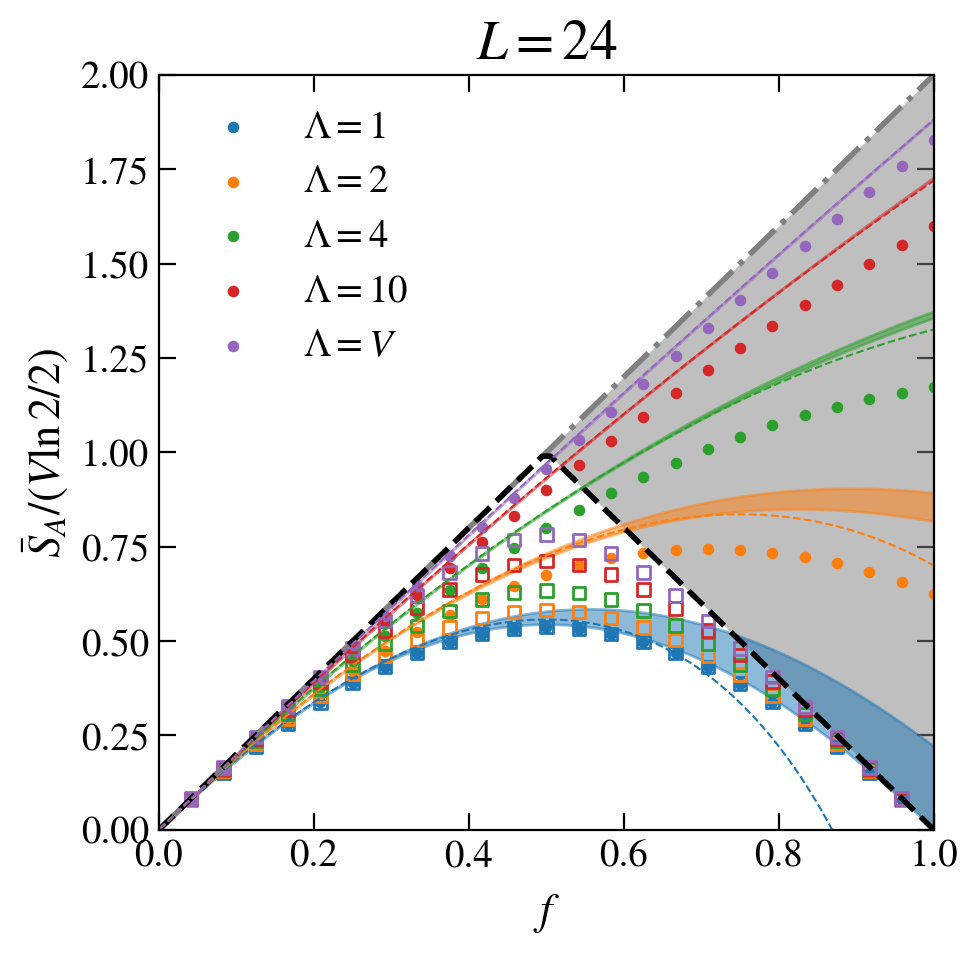

In [803]:
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)

ff = np.linspace(0, 1.0, 100)
axis.plot(ff, 2*ff, ls='-.', color='gray', lw=2)
axis.plot(ff, 1 - 2*np.abs(0.5 - ff), ls='--', color='k', lw=2)
axis.fill_between(ff, 1 - 2*np.abs(0.5 - ff), 2*ff, color='gray', alpha=0.5, lw=0)

# ff = np.linspace(0., 0.5, 100)
# axis.plot(ff, 2 * ff * (1 - (1 + (1-ff)/ff * np.log(1-ff) ) / np.log(2)), ls=':', color='black')
# ff = np.linspace(.5, 1., 100)
# axis.plot(ff, 2 * (1-ff) * (1 - (1 + ff/(1-ff) * np.log(ff) ) / np.log(2)), ls=':', color='black')    

colors_ls_cyc = itertools.cycle(colors_ls)
L = 100
w = 1
J = 1
g = 0.618


L=24
V=L
op=0
prefix = base_dir(model='SYK2', d=1) + 'Entropy/Degeneracy/'
# if op == 2:   prefix += "AllStates/"
# else:         prefix += "RandomChoice/"
prefix += "RandomChoice/"
if op == 1:   prefix += "SameHamiltonian/"
else:         prefix += "DifferentHamiltonian/"
    
name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
# print(name)


if exists(name):
    with h5py.File(name, "r") as file:
        subsizes = np.array(file.get('subsystem_sizes'))
        Gammas = np.array(file.get('Gammas'))
        S = np.zeros((subsizes.size+1, Gammas.size))
        S[:-1, :] = np.array(file.get('entropy_corr_mat')) / (V//2*np.log(2))
        S[-1, :] = np.array(file.get('Non-Gaussianity')) / (V//2*np.log(2))
        # print(S)
        Sent = np.array(file.get('entropy')) / (V//2*np.log(2))

subsizes = np.array([*subsizes, V])
# print(S)

# Gammas = np.array([1, 2, 4, 10, V//2, V, 2*V, int(V*np.log(V))]) if V < 26 else np.array([1, 2, 4, 10, V//2, V])
names = [r"$\Lambda=1$",r"$\Lambda=2$",r"$\Lambda=4$",r"$\Lambda=10$", r"$\Lambda=\frac{V}{2}$", r"$\Lambda=V$", r"$\Lambda=2V$", r"$\Lambda=V\ln{V}$"]
indices = [0, 1, 2, 3, 5]
colors_ls_cyc = itertools.cycle(colors_ls)
for ii in indices:
    nam = names[ii]
    gam = Gammas[ii]
    col = next(colors_ls_cyc)

    ff = np.linspace(0, 1, 1000)
    axis.plot(ff, 2 * ff * s_QCQ(ff, gam), ls='--', color=col, lw=0.75)
    axis.fill_between(ff, 2*ff*QC_lower_bound(f=ff, x=gam, n=3), 2*ff*QC_upper_bound(f=ff, x=gam, n=3), alpha=0.5, color=col)
    
    # print(2 * ff * ( 1 - (s_QCQ(ff, gam)) / (np.log(2)) ))
    
    # ff = np.linspace(0.5, 1.0, 100)
    # axis.plot(ff, 2*(1-ff)*s_QCQ(1-ff, gam), ls='-', color=col, lw=0.75)

    axis.scatter(subsizes / L, S[:, ii], marker = 'o', color=col, s=10, label=nam)
    axis.scatter(subsizes[:-1] / L, Sent[:, ii], marker = 's', color=col, s=20, facecolor='None')
    # axis.scatter(1 - subsizes[::5] / L, S[::5,gam - 1], color=col, s=10, facecolor='None')
    # axis.axvline(x=np.sqrt(gam), ls=':', color=col)
    
fig_help.set_plot_elements(axis, ylabel=r"${\bar{S}_A} / (V\ln2/2)$", xlabel=r"$f$", font_size=14, set_legend=True, xlim=(0,1), ylim=(0,2), xscale='linear', yscale='linear')
axis.set_title(r"$L=%d$"%L, fontsize = 20)


No handles with labels found to put in legend.


Text(0.5, 1.0, '$\\Lambda=V$')

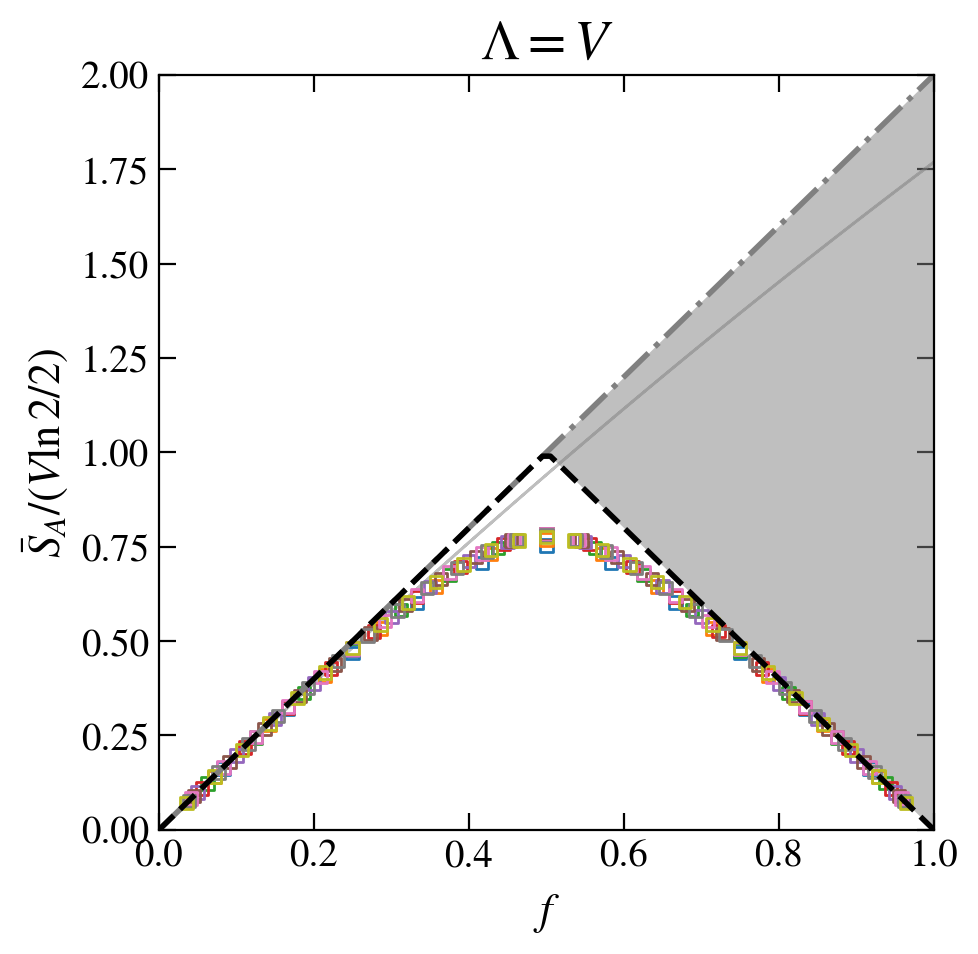

In [804]:
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)

ff = np.linspace(0, 1.0, 100)
axis.plot(ff, 2*ff, ls='-.', color='gray', lw=2)
axis.plot(ff, 1 - 2*np.abs(0.5 - ff), ls='--', color='k', lw=2)
axis.fill_between(ff, 1 - 2*np.abs(0.5 - ff), 2*ff, color='gray', alpha=0.5, lw=0)

# ff = np.linspace(0., 0.5, 100)
# axis.plot(ff, 2 * ff * (1 - (1 + (1-ff)/ff * np.log(1-ff) ) / np.log(2)), ls=':', color='black')
# ff = np.linspace(.5, 1., 100)
# axis.plot(ff, 2 * (1-ff) * (1 - (1 + ff/(1-ff) * np.log(ff) ) / np.log(2)), ls=':', color='black')    

colors_ls_cyc = itertools.cycle(colors_ls)
L = 100
w = 1
J = 1
g = 0.618


L=24
V=L
op=0
prefix = base_dir(model='SYK2', d=1) + 'Entropy/Degeneracy/'
# if op == 2:   prefix += "AllStates/"
# else:         prefix += "RandomChoice/"
prefix += "RandomChoice/"
if op == 1:   prefix += "SameHamiltonian/"
else:         prefix += "DifferentHamiltonian/"
    
# print(name)

sizes = np.arange(12, 29, 2)

# Gammas = np.array([1, 2, 4, 10, V//2, V, 2*V, int(V*np.log(V))]) if V < 26 else np.array([1, 2, 4, 10, V//2, V])
names = [r"$\Lambda=1$",r"$\Lambda=2$",r"$\Lambda=4$",r"$\Lambda=10$", r"$\Lambda=\frac{V}{2}$", r"$\Lambda=V$", r"$\Lambda=2V$", r"$\Lambda=V\ln{V}$"]
idx = 5

for L in sizes:
    V = L
    name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
    if exists(name):
        with h5py.File(name, "r") as file:
            subsizes = np.array(file.get('subsystem_sizes'))
            Gammas = np.array(file.get('Gammas'))
            if idx < Gammas.size:
                nam = names[idx]
                gam = Gammas[idx]
                S = np.zeros((subsizes.size+1, Gammas.size))
                S[:-1, :] = np.array(file.get('entropy_corr_mat')) / (V//2*np.log(2))
                S[-1, :] = np.array(file.get('Non-Gaussianity')) / (V//2*np.log(2))
                # print(S)
                Sent = np.array(file.get('entropy'))[:, idx] / (V//2*np.log(2))

                col = next(colors_ls_cyc)
                if L == sizes[0]:
                    ff = np.linspace(0, 1, 1000)
                    # axis.plot(ff, 2 * ff * s_QCQ(ff, gam), ls='--', color='k', lw=0.75)
                    axis.fill_between(ff, 2*ff*QC_lower_bound(f=ff, x=gam, n=3), 2*ff*QC_upper_bound(f=ff, x=gam, n=3), alpha=0.5, color='gray')
                
                # axis.scatter(subsizes / L, S[:, ii], marker = 'o', color=col, s=10, label=nam)
                axis.scatter(subsizes / L, Sent, marker = 's', color=col, s=20, facecolor='None')
            
fig_help.set_plot_elements(axis, ylabel=r"${\bar{S}_A} / (V\ln2/2)$", xlabel=r"$f$", font_size=14, set_legend=True, xlim=(0,1), ylim=(0,2), xscale='linear', yscale='linear')
axis.set_title(nam, fontsize = 20)


../results/SYK2/GOE/Entropy/Degeneracy/RandomChoice/DifferentHamiltonian/
../results/SYK2/GOE/Entropy/Degeneracy/RandomChoice/SameHamiltonian/
../results/SYK2/GOE/Entropy/Degeneracy/RandomChoice/DifferentHamiltonian/
../results/SYK2/GOE/Entropy/Degeneracy/RandomChoice/SameHamiltonian/
../results/SYK2/GOE/Entropy/Degeneracy/RandomChoice/DifferentHamiltonian/
../results/SYK2/GOE/Entropy/Degeneracy/RandomChoice/SameHamiltonian/
../results/SYK2/GOE/Entropy/Degeneracy/RandomChoice/DifferentHamiltonian/
../results/SYK2/GOE/Entropy/Degeneracy/RandomChoice/SameHamiltonian/


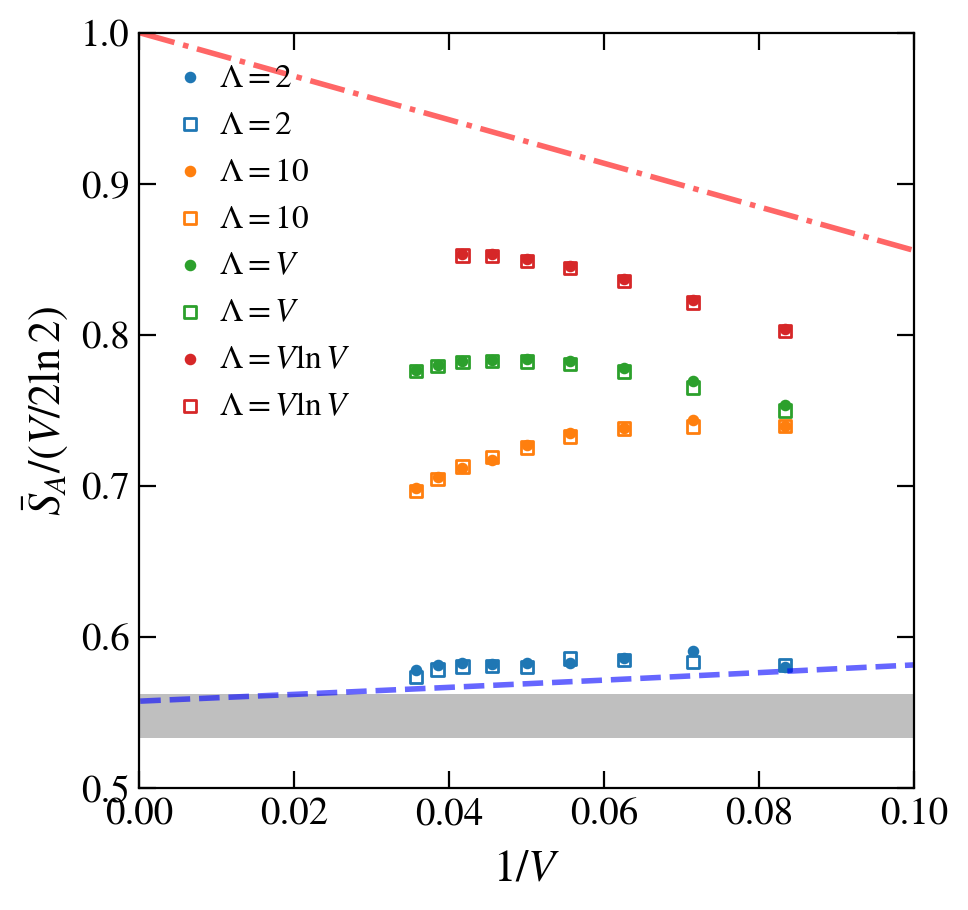

In [5]:
L = 100
w = 1
J = 1
g = 0.618



fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)
# fig, axis_flu

op=1

def _get_prefix(_op):
    prefix = base_dir(model='SYK2', d=1) + 'Entropy/Degeneracy/'
    prefix += "RandomChoice/"
    if _op == 1:   prefix += "SameHamiltonian/"
    else:          prefix += "DifferentHamiltonian/"
    return prefix

prefix = _get_prefix(op)

colors_ls_cyc = itertools.cycle(colors_ls)
sizes = np.arange(12, 29, 2)

subsize_idx = -1

names = [r"$\Lambda=1$",r"$\Lambda=2$",r"$\Lambda=4$",r"$\Lambda=10$", r"$\Lambda=\frac{V}{2}$", r"$\Lambda=V$", r"$\Lambda=2V$", r"$\Lambda=V\ln{V}$"]
indices = [1, 3, 5, 7]
colors_ls_cyc = itertools.cycle(colors_ls)
for ii in indices:
    nam = names[ii]
    sizes = np.arange(12, 29, 2) if ii < 6 else np.arange(12, 25, 2)
    col = next(colors_ls_cyc)
    
    for op in [0, 1]:
        prefix = _get_prefix(op)
        print(prefix)
        S = np.zeros(sizes.shape)
        for id_L, L in enumerate(sizes):
            V = L
            name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
            # print(name)
            if exists(name):
                with h5py.File(name, "r") as file:
                    gams = np.array(file.get('Gammas'))
                    subsystem = np.array(file.get('subsystem_sizes'))
                    idx = np.argmin( np.abs(subsystem - V//2) )
                    entrop = np.array(file.get('entropy'))
                    S[id_L] = entrop[idx, ii] / (L//2 * np.log(2))
            else:
                print(name)

        axis.scatter(1/sizes, S, marker='s' if op else 'o', s=10 + 10*op, color=col, facecolor='None' if op else col, label=r"%s"%(nam))

fig_help.set_plot_elements(axis, ylabel=r"${\bar{S}_A} / (V/2\ln2)$", xlabel=r"$1/V$", font_size=14, set_legend=True, xlim=(0, 0.1), ylim=(0.5, 1.0), xscale='linear', yscale='linear')
axis.legend(loc = 'upper left', ncol=1, columnspacing=0.4, frameon=False, fontsize=12, handletextpad=0.25, handlelength = 1.25)

z = np.linspace(0, 0.1, 1000)
Lz = 1/z
yy = ent.gaussian_page(Lz/2, Lz/2) / (Lz/2 * np.log(2))
axis.plot(z, yy, ls='--', color='blue', lw=2, alpha=0.6, label=r"Gaussian $U(1)$")
axis.plot(z, [ent.page_asy(Lx/2, Lx/2) / (Lx/2 * np.log(2)) for Lx in Lz], ls='-.', color='red', lw=2, alpha=0.6, label=r"Page $U(1)$")
axis.axhspan(ymin = FF_lower_bound(f=1/2, x=1, n=4), ymax = FF_upper_bound(f=1/2, x=1, n=4), color='gray', lw=0, alpha=0.5)


# fig_help.set_plot_elements(ax_inset, ylabel=r"${\bar{S}_A} / \ln2$", xlabel=r"$W$", font_size=14, set_legend=False, xlim=(8.0, 25.0), ylim=(0.7, 1.0))

fig.subplots_adjust(wspace = 0.3, hspace=0.05)


[0.06936047 0.07540923 0.0831582  0.08388605 0.08264866 0.08663166
 0.09529536 0.09013944 0.08736358]
[0.12818815 0.1317104  0.13683183 0.14296446 0.14850351 0.15149028
 0.16010322 0.16265166 0.16640074]
[0.14759949 0.15521218 0.15933691 0.16685411 0.17466822 0.1822504
 0.18799475 0.19589453 0.20348366]
[0.1582678  0.15809008 0.1597837  0.16114823 0.1658286  0.16877953
 0.17453815 0.18000585 0.18530694]


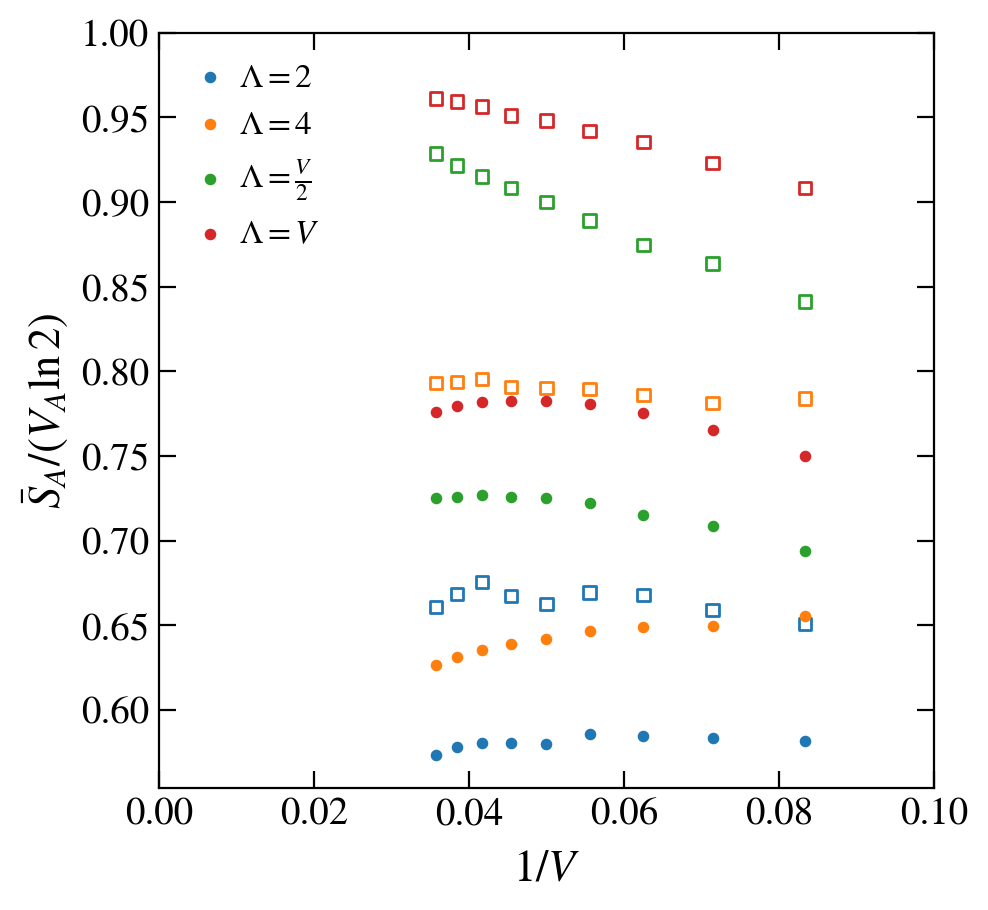

In [806]:
L = 100
w = 1
J = 1
g = 0.618



fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)
# fig, axis_flu

op = 1

def _get_prefix(_op):
    prefix = base_dir(model='SYK2', d=1) + 'Entropy/Degeneracy/'
    prefix += "RandomChoice/"
    if _op == 1:   prefix += "SameHamiltonian/"
    else:          prefix += "DifferentHamiltonian/"
    return prefix

prefix = _get_prefix(op)

colors_ls_cyc = itertools.cycle(colors_ls)

f = 1/2

names = [r"$\Lambda=1$",r"$\Lambda=2$",r"$\Lambda=4$",r"$\Lambda=10$", r"$\Lambda=\frac{V}{2}$", r"$\Lambda=V$", r"$\Lambda=2V$", r"$\Lambda=V\ln{V}$"]
indices = [1, 2, 4, 5]
colors_ls_cyc = itertools.cycle(colors_ls)
for ii in indices:
    nam = names[ii]
    sizes = np.arange(12, 29, 4 if f == 1/4 else 2) if ii < 6 else np.arange(12, 25, 4 if f == 1/4 else 2)
    col = next(colors_ls_cyc)
    
    S = np.zeros(sizes.shape)
    S_corr = np.zeros(sizes.shape)
    for id_L, L in enumerate(sizes):
        V = L
        VA = int( V * f ) if f > 0 else 1
        name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
        # print(name)
        if exists(name):
            with h5py.File(name, "r") as file:
                gams = np.array(file.get('Gammas'))
                
                subsystem = np.array(file.get('subsystem_sizes'))
                idx = np.argmin( np.abs(subsystem - VA) )
                
                ent = np.array(file.get('entropy'))
                S[id_L] = ent[idx, ii] / (VA * np.log(2))
                
                ent = np.array(file.get('entropy_corr_mat'))
                S_corr[id_L] = ent[idx, ii] / (VA * np.log(2))
        else:
            print(name)

    axis.scatter(1/sizes, S, marker='o', s=10, color=col, facecolor=col, label=r"%s"%(nam))
    axis.scatter(1/sizes, S_corr, marker='s', s=20, color=col, facecolor='None')
    # axis.scatter(1/sizes, S / S_corr, marker='s', s=20, color=col, facecolor='None', label=r"%s"%(nam))
    print(S_corr - S)
fig_help.set_plot_elements(axis, ylabel=r"${\bar{S}_A} / (V_A\ln2)$" if f > 0 else r"${\bar{S}_\ell} / (\ln2)$", xlabel=r"$1/V$", font_size=14, set_legend=True, xlim=(0, 0.1), ylim=(None, 1), xscale='linear', yscale='linear')
axis.legend(loc = 'upper left', ncol=1, columnspacing=0.4, frameon=False, fontsize=12, handletextpad=0.25, handlelength = 1.25)
axis.set_ylim(None, 1)

# fig_help.set_plot_elements(ax_inset, ylabel=r"${\bar{S}_A} / \ln2$", xlabel=r"$W$", font_size=14, set_legend=False, xlim=(8.0, 25.0), ylim=(0.7, 1.0))

fig.subplots_adjust(wspace = 0.3, hspace=0.05)


4 0.5
5 1


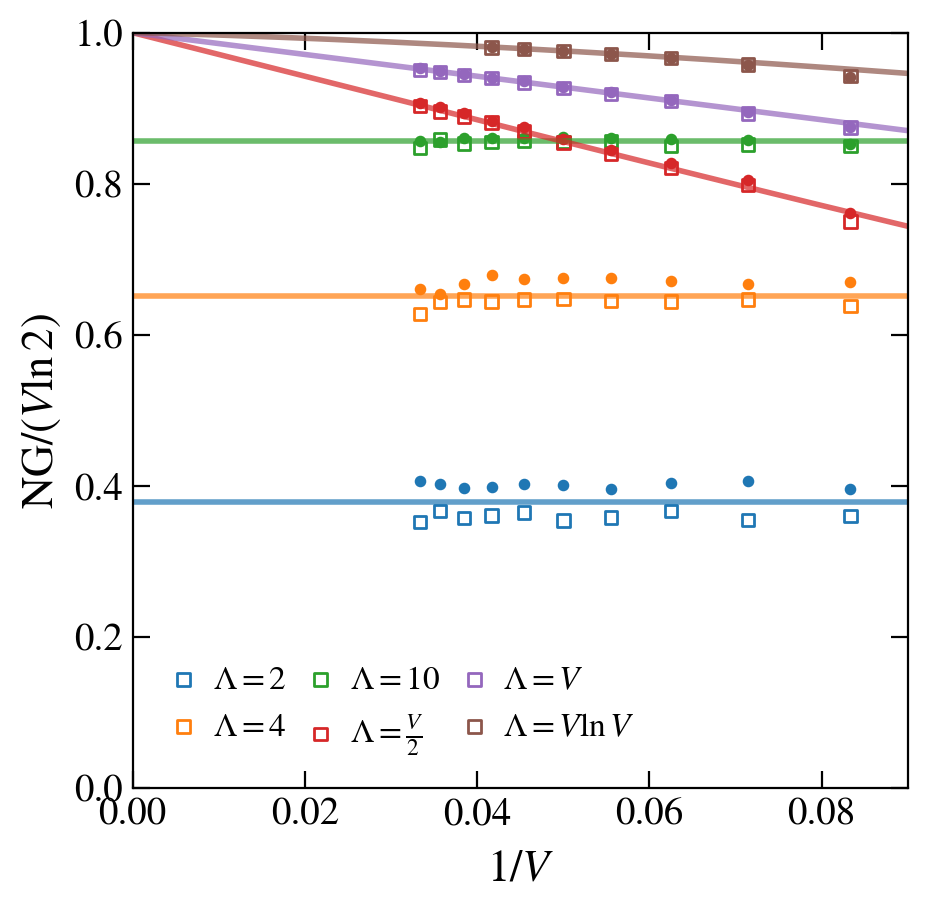

In [807]:
L = 100
w = 1
J = 1
g = 0.618



fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)
# fig, axis_flu

op = 1

def _get_prefix(_op):
    prefix = base_dir(model='SYK2', d=1, ensemble='GUE') + 'Entropy/Degeneracy/'
    prefix += "RandomChoice/"
    if _op == 1:   prefix += "SameHamiltonian/"
    else:          prefix += "DifferentHamiltonian/"
    return prefix

prefix = _get_prefix(op)

colors_ls_cyc = itertools.cycle(colors_ls)

f = 1/2

names = [r"$\Lambda=1$",r"$\Lambda=2$",r"$\Lambda=4$",r"$\Lambda=10$", r"$\Lambda=\frac{V}{2}$", r"$\Lambda=V$", r"$\Lambda=2V$", r"$\Lambda=V\ln{V}$"]
indices = [1, 2, 3, 4, 5, 7]

colors_ls_cyc = itertools.cycle(colors_ls)
for ii in indices:
    nam = names[ii]
    sizes = np.arange(12, 31, 2) if ii < 6 else np.arange(12, 25, 2)
    col = next(colors_ls_cyc)
    
    for op in [0,1]:
        prefix = _get_prefix(op)
        NG_diff = np.zeros(sizes.shape)
        for id_L, L in enumerate(sizes):
            V = L
            VA = int( V * f )
            name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
            # print(name)
            if exists(name):
                with h5py.File(name, "r") as file:
                    gams = np.array(file.get('Gammas'))
                    NG = np.array(file.get('Non-Gaussianity'))
                    NG_diff[id_L] = NG[ii] / (V * np.log(2))
            else:
                print(name)

        axis.scatter(1/sizes, NG_diff, marker='s' if op else 'o', s=10 + 10*op, color=col, facecolor='None' if op else col, label=r"%s"%(nam) if op else '')
    if ii < 4:
        axis.axhline(y = NonGaussianity(gams[ii], n=10), color = col, alpha=0.7, lw=2)
    elif ii < 7:
        x = np.linspace(0, 2/min(sizes), 1000)
        print(ii, 2**(ii-5))
        axis.plot(x, NonGaussianity(1/x * 2**(ii-5), n=10), color = col, alpha=0.7, lw=2)
    else:
        axis.plot(x, NonGaussianity(1/x * np.log(1/x), n=10), color = col, alpha=0.7, lw=2)

fig_help.set_plot_elements(axis, ylabel=r"${\rm NG} / (V\ln2)$", xlabel=r"$1/V$", font_size=14, set_legend=True, xlim=(0, 0.09), ylim=(0, 1), xscale='linear', yscale='linear')
axis.legend(loc = 'lower left', ncol=3, columnspacing=0.4, frameon=False, fontsize=12, handletextpad=0.25, handlelength = 1.25)


# fig_help.set_plot_elements(ax_inset, ylabel=r"${\bar{S}_A} / \ln2$", xlabel=r"$W$", font_size=14, set_legend=False, xlim=(8.0, 25.0), ylim=(0.7, 1.0))

fig.subplots_adjust(wspace = 0.3, hspace=0.05)


## COMPARE MIXING DIFFERENT HAMILTONIANS TO NEGLECTING $\langle \alpha|f_q^\dagger f_q'|\beta\rangle$ terms

0.03189299760781444 0.4147239133245464
0.037607961456629556 0.395869230737986
0.04621983974675864 0.39038946979969175
0.07008950219185019 0.3979189721949218
0.01301138163315894 0.40869800965111064
0.02907160313506046 0.4066620855391084
0.030054081732171334 0.38829076249073113
0.038921133315916824 0.3916843251964263
0.0050993010517455155 0.4655587799107026
0.009826168989583725 0.39708515413147494
0.044842343437642325 0.41761267432561056
0.027443579232196664 0.3923827433446451


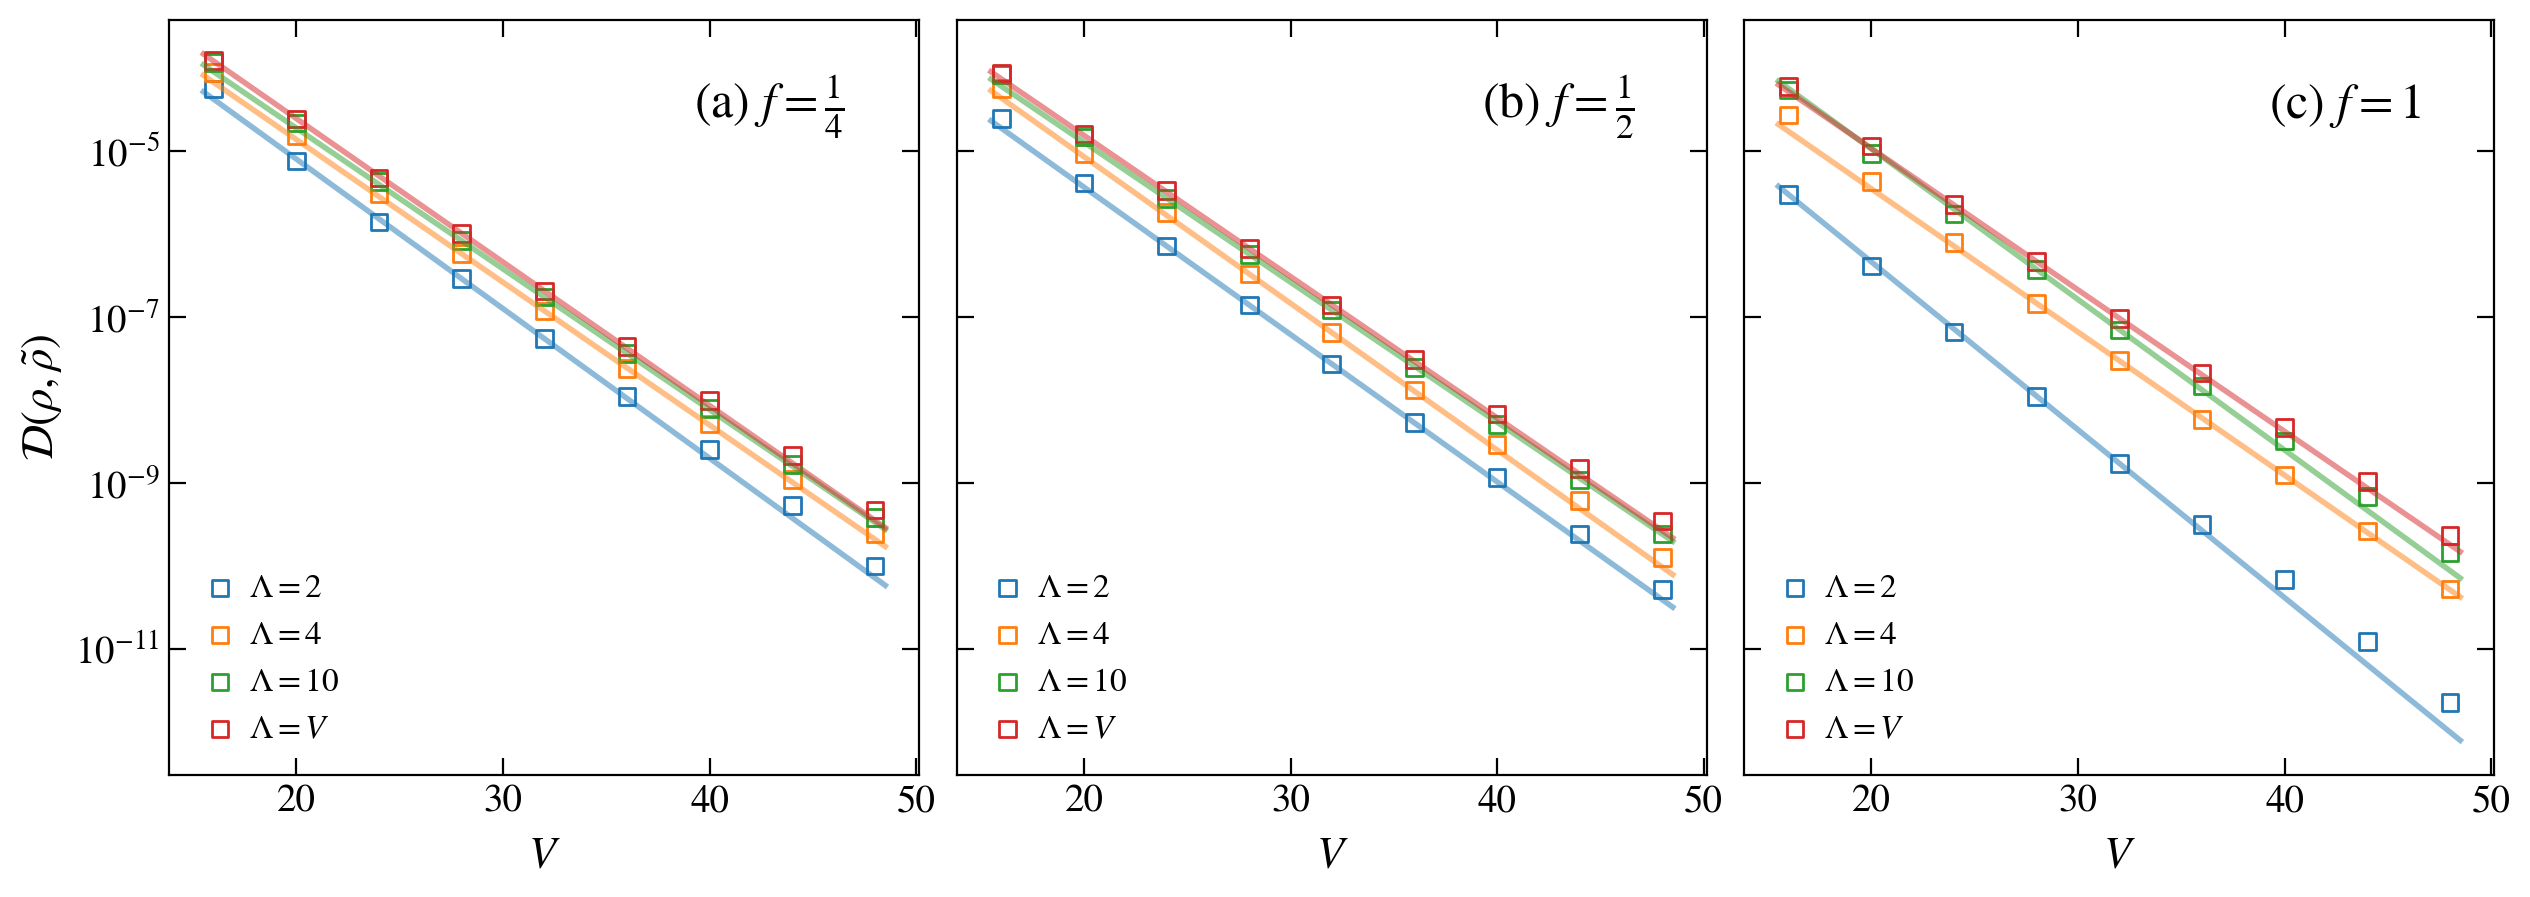

In [5]:
L = 100
w = 1
J = 1
g = 0.618



fig, axis = plt.subplots( nrows=1, ncols=3, figsize=(15,5), dpi = 200, sharey=True)
# fig, axis_flu

op = 0
ensemble = 'GUE'

prefix = base_dir(model='SYK2', d=1, ensemble=ensemble) + 'Entropy/NonGaussianity/'
prefix += "RandomChoice/"
if op == 1:   prefix += "SameHamiltonian/"
else:          prefix += "DifferentHamiltonian/"

colors_ls_cyc = itertools.cycle(colors_ls)

f = 1/4

names = [r"$\Lambda=1$",r"$\Lambda=2$",r"$\Lambda=3$",r"$\Lambda=4$",r"$\Lambda=10$",r"$\Lambda=20$", r"$\Lambda=\frac{V}{2}$", r"$\Lambda=V$"]
indices = [1, 3, 4, 7]

for iif, f in enumerate([1/4, 1/2, 1]):
    colors_ls_cyc = itertools.cycle(colors_ls)
    for ii in indices:
        nam = names[ii]
        sizes = np.arange(16, 49, 4)
        col = next(colors_ls_cyc)

        TD = np.zeros(sizes.shape)
        # Gam = np.zeros(sizes.shape)
        for id_L, L in enumerate(sizes):
            V = L
            VA = int( V * f )
            name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
            # print(name)
            if exists(name):
                with h5py.File(name, "r") as file:
                    gams = np.array(file.get('Gammas'))
                    G = gams[ii]
                    TD[id_L] = np.array(file.get('TraceDistance'))[int(f*V)-1, ii]
            else:
                print(name)

        axis[iif].scatter(sizes, TD, marker='s', color=col, facecolor='None', label=r"%s"%(nam))
        
        def prob_fit(V, a, b):
            return a * np.exp(-b * V)
                                
        sizes = sizes[~np.isnan(TD)]
        TD = TD[~np.isnan(TD)]
        if TD.size > 2:
            # print(iif, G, TD)
            pars, pconv= fit(prob_fit,
                            xdata = sizes[-6:],
                            ydata = TD[-6:],
                            maxfev = 20000)
            print(*pars)
            z = np.linspace(min(sizes)-0.5, max(sizes)+0.5, 1000)
            axis[iif].plot(z, prob_fit(z, *pars), color=col, lw=2, alpha=0.5)
        
        # axis.plot(1/sizes, Gamma(G) / ( binom(sizes,sizes//2) / (sizes**2 / 4 + 1) )**(G-1), color=col, lw=2, alpha=0.5)

    fig_help.set_plot_elements(axis[iif], ylabel=r"$\mathcal{D}(\rho,\tilde{\rho})$" if iif==0 else "", xlabel=r"$V$", font_size=14, set_legend=True, xscale='linear', yscale='log')
    axis[iif].legend(loc = 'lower left', ncol=1, columnspacing=0.4, frameon=False, fontsize=12, handletextpad=0.25, handlelength = 1.25)
    # axis.set_xlim(0, None)

axis[0].annotate(r"(a) $f=\frac{1}{4}$", fontsize=18, xy=(0.7, 0.87), xycoords='axes fraction')
axis[1].annotate(r"(b) $f=\frac{1}{2}$", fontsize=18, xy=(0.7, 0.87), xycoords='axes fraction')
axis[2].annotate(r"(c) $f=1$", fontsize=18, xy=(0.7, 0.87), xycoords='axes fraction')
# fig_help.set_plot_elements(ax_inset, ylabel=r"${\bar{S}_A} / \ln2$", xlabel=r"$W$", font_size=14, set_legend=False, xlim=(8.0, 25.0), ylim=(0.7, 1.0))

fig.subplots_adjust(wspace = 0.05, hspace=0.05)


1 0.125 0.017850760308581185 0.3745254129222436
1 0.25 0.01903402195044585 0.3987484225517779
1 0.5 0.011529025141958572 0.40495524166291436
1 1 0.0011685572671944358 0.4198265008705995
4 0.125 0.022535012604455527 0.35586860057838743
4 0.25 0.0446615255536915 0.389329903814689
4 0.5 0.04183111903541734 0.39850630384301267
4 1 0.017434673785731648 0.3883759784414174
7 0.125 0.031002670962260243 0.3618507291007562
7 0.25 0.04371875741897852 0.3833314960640049
7 0.5 0.02502914484932352 0.3780473382635199
7 1 0.01719888973505052 0.37794849441640654


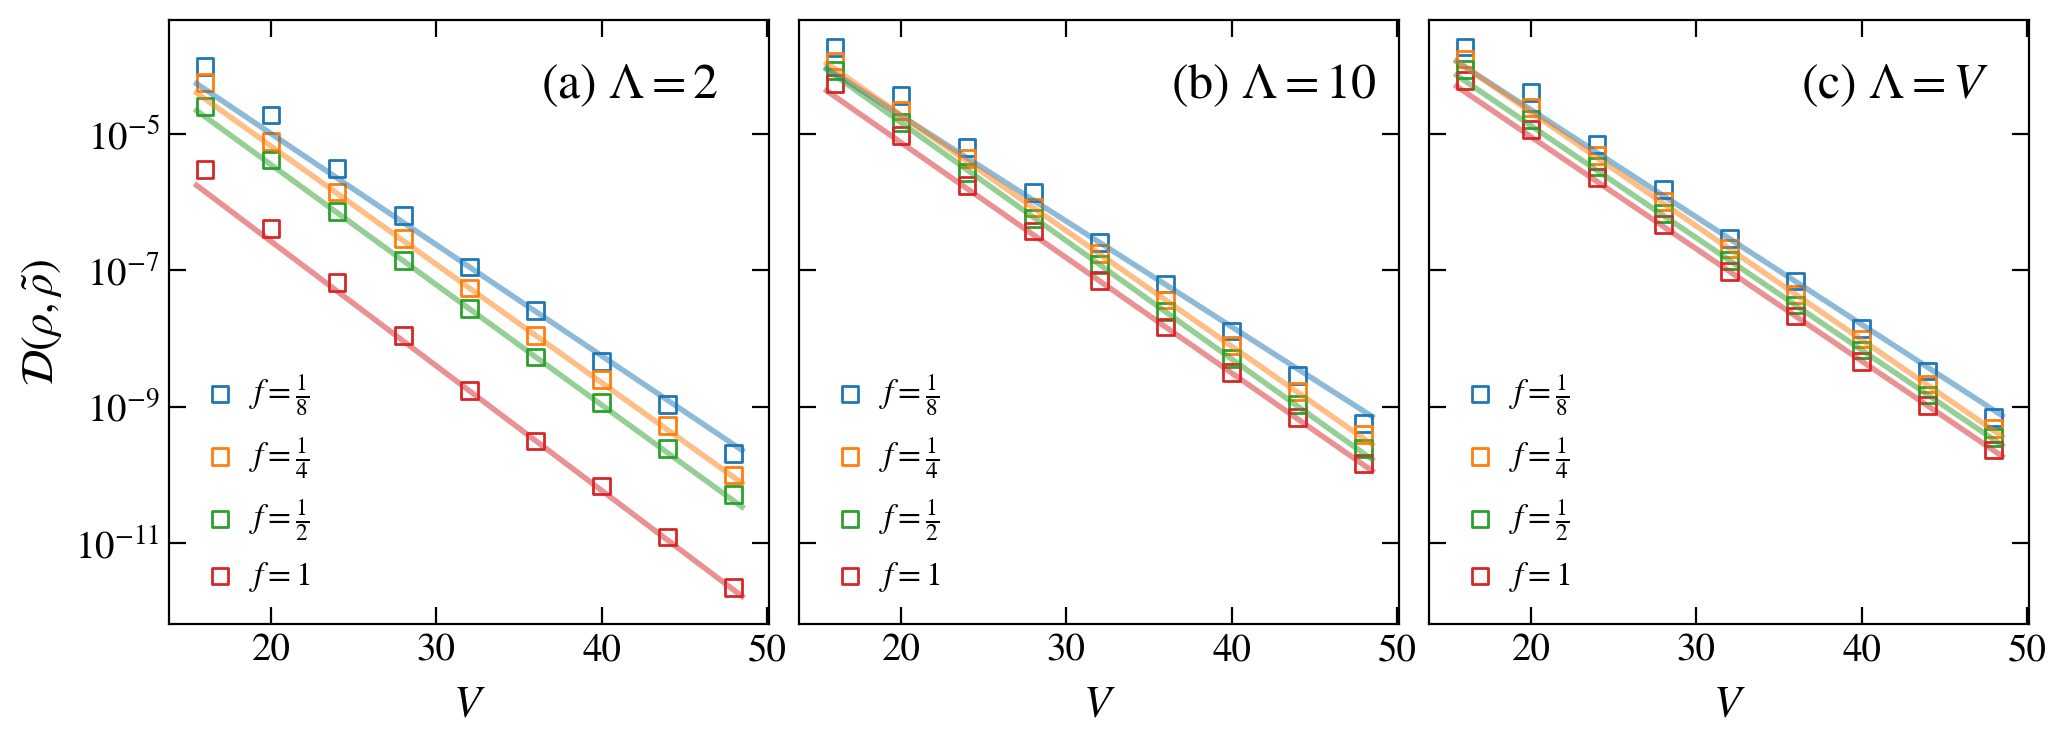

In [6]:
L = 100
w = 1
J = 1
g = 0.618



fig, axis = plt.subplots( nrows=1, ncols=3, figsize=(12,4), dpi = 200, sharey=True)
# fig, axis_flu

op = 0
ensemble = 'GUE'

prefix = base_dir(model='SYK2', d=1, ensemble=ensemble) + 'Entropy/NonGaussianity/'
prefix += "RandomChoice/"
if op == 1:   prefix += "SameHamiltonian/"
else:          prefix += "DifferentHamiltonian/"

colors_ls_cyc = itertools.cycle(colors_ls)

f = 1/4

names = [r"$\Lambda=1$",r"$\Lambda=2$",r"$\Lambda=3$",r"$\Lambda=4$",r"$\Lambda=10$",r"$\Lambda=20$", r"$\Lambda=\frac{V}{2}$", r"$\Lambda=V$"]
indices = [1, 4, 7]

for id, ii in enumerate(indices):
    nam = names[ii]
    colors_ls_cyc = itertools.cycle(colors_ls)
    for iif, f in enumerate([1/8, 1/4, 1/2, 1]):
        # sizes = np.array([20, 24, 28, 32, 40, 48, 56]) if int(1/f) == 8 else 
        sizes = np.arange(16, 49, 4)
        
        col = next(colors_ls_cyc)

        TD = np.zeros(sizes.shape)
        # Gam = np.zeros(sizes.shape)
        for id_L, L in enumerate(sizes):
            V = L
            VA = int( V * f )
            name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
            # print(name)
            if exists(name):
                with h5py.File(name, "r") as file:
                    gams = np.array(file.get('Gammas'))
                    G = gams[ii]
                    TD[id_L] = np.array(file.get('TraceDistance'))[int(f*V)-1, ii]
            else:
                print(name)

        axis[id].scatter(sizes, TD, marker='s', color=col, facecolor='None', label=r"$f=\frac{1}{%d}$"%(1/f) if f < 1 else r"$f=1$")
        
        def prob_fit(V, a, b):
            return a * np.exp(-b * V)
                                
        sizes = sizes[~np.isnan(TD)]
        TD = TD[~np.isnan(TD)]
        if TD.size > 2:
            # print(iif, G, TD)
            pars, pconv= fit(prob_fit,
                            xdata = sizes[-5:],
                            ydata = TD[-5:],
                            maxfev = 20000)
            print(ii, f, *pars)
            z = np.linspace(min(sizes)-0.5, max(sizes)+0.5, 1000)
            axis[id].plot(z, prob_fit(z, *pars), color=col, lw=2, alpha=0.5)
        
        # axis.plot(1/sizes, Gamma(G) / ( binom(sizes,sizes//2) / (sizes**2 / 4 + 1) )**(G-1), color=col, lw=2, alpha=0.5)

    fig_help.set_plot_elements(axis[id], ylabel=r"$\mathcal{D}(\rho,\tilde{\rho})$" if id==0 else "", xlabel=r"$V$", font_size=14, set_legend=True, xscale='linear', yscale='log')
    axis[id].legend(loc = 'lower left', ncol=1, columnspacing=0.4, frameon=False, fontsize=12, handletextpad=0.25, handlelength = 1.25)
    # axis.set_xlim(0, None)

axis[0].annotate(r"(a) " + names[indices[0]], fontsize=18, xy=(0.62, 0.87), xycoords='axes fraction')
axis[1].annotate(r"(b) " + names[indices[1]], fontsize=18, xy=(0.62, 0.87), xycoords='axes fraction')
axis[2].annotate(r"(c) " + names[indices[2]], fontsize=18, xy=(0.62, 0.87), xycoords='axes fraction')
# fig_help.set_plot_elements(ax_inset, ylabel=r"${\bar{S}_A} / \ln2$", xlabel=r"$W$", font_size=14, set_legend=False, xlim=(8.0, 25.0), ylim=(0.7, 1.0))

fig.subplots_adjust(wspace = 0.05, hspace=0.05)


## COMPARE $\overline{ {\rm Tr}J^{2n} }$ for small $n$ to analytic result

0 0 8500
0 1 8500
0 2 8500
0 3 8500
0 4 8500
0 5 8500
0 6 8497
0 7 8487
0 8 7439
0 9 2231
0 10 1635
0 11 894
0 12 522
0 13 323
0 14 192
0 15 119
0 16 71
0 17 60
1 0.5 [1.67993271e-05 4.30225749e-06 2.09731502e-05 3.94242811e-06
 3.07659442e-06 3.40457216e-06 1.30513040e-07 4.53472223e-06
 3.42288493e-06 7.47292838e-06 9.45029379e-06 8.24427132e-06
 1.44047506e-06 4.37433866e-06 2.21992810e-05 1.59784976e-05
 5.73535375e-06 1.02127720e-05]
0 0 8500
0 1 8500
0 2 8500
0 3 8500
0 4 8500
0 5 8500
0 6 8497
0 7 8487
0 8 7439
0 9 2231
0 10 1635
0 11 894
0 12 522
0 13 323
0 14 192
0 15 119
0 16 71
0 17 60
1 1 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
1 0 8500
1 1 8500
1 2 8500
1 3 8500
1 4 8500
1 5 8500
1 6 8497
1 7 8487
1 8 7439
1 9 2231
1 10 1635
1 11 894
1 12 522
1 13 323
1 14 192
1 15 119
1 16 71
1 17 60
2 0.5 [5.08472576e-05 2.51779355e-04 4.78419068e-04 6.12047068e-04
 9.08147622e-04 3.71535078e-04 1.52058259e-05 7.57416644e-04
 5.25486985e-04 4.21854485e-04 2.50454763e-03 2

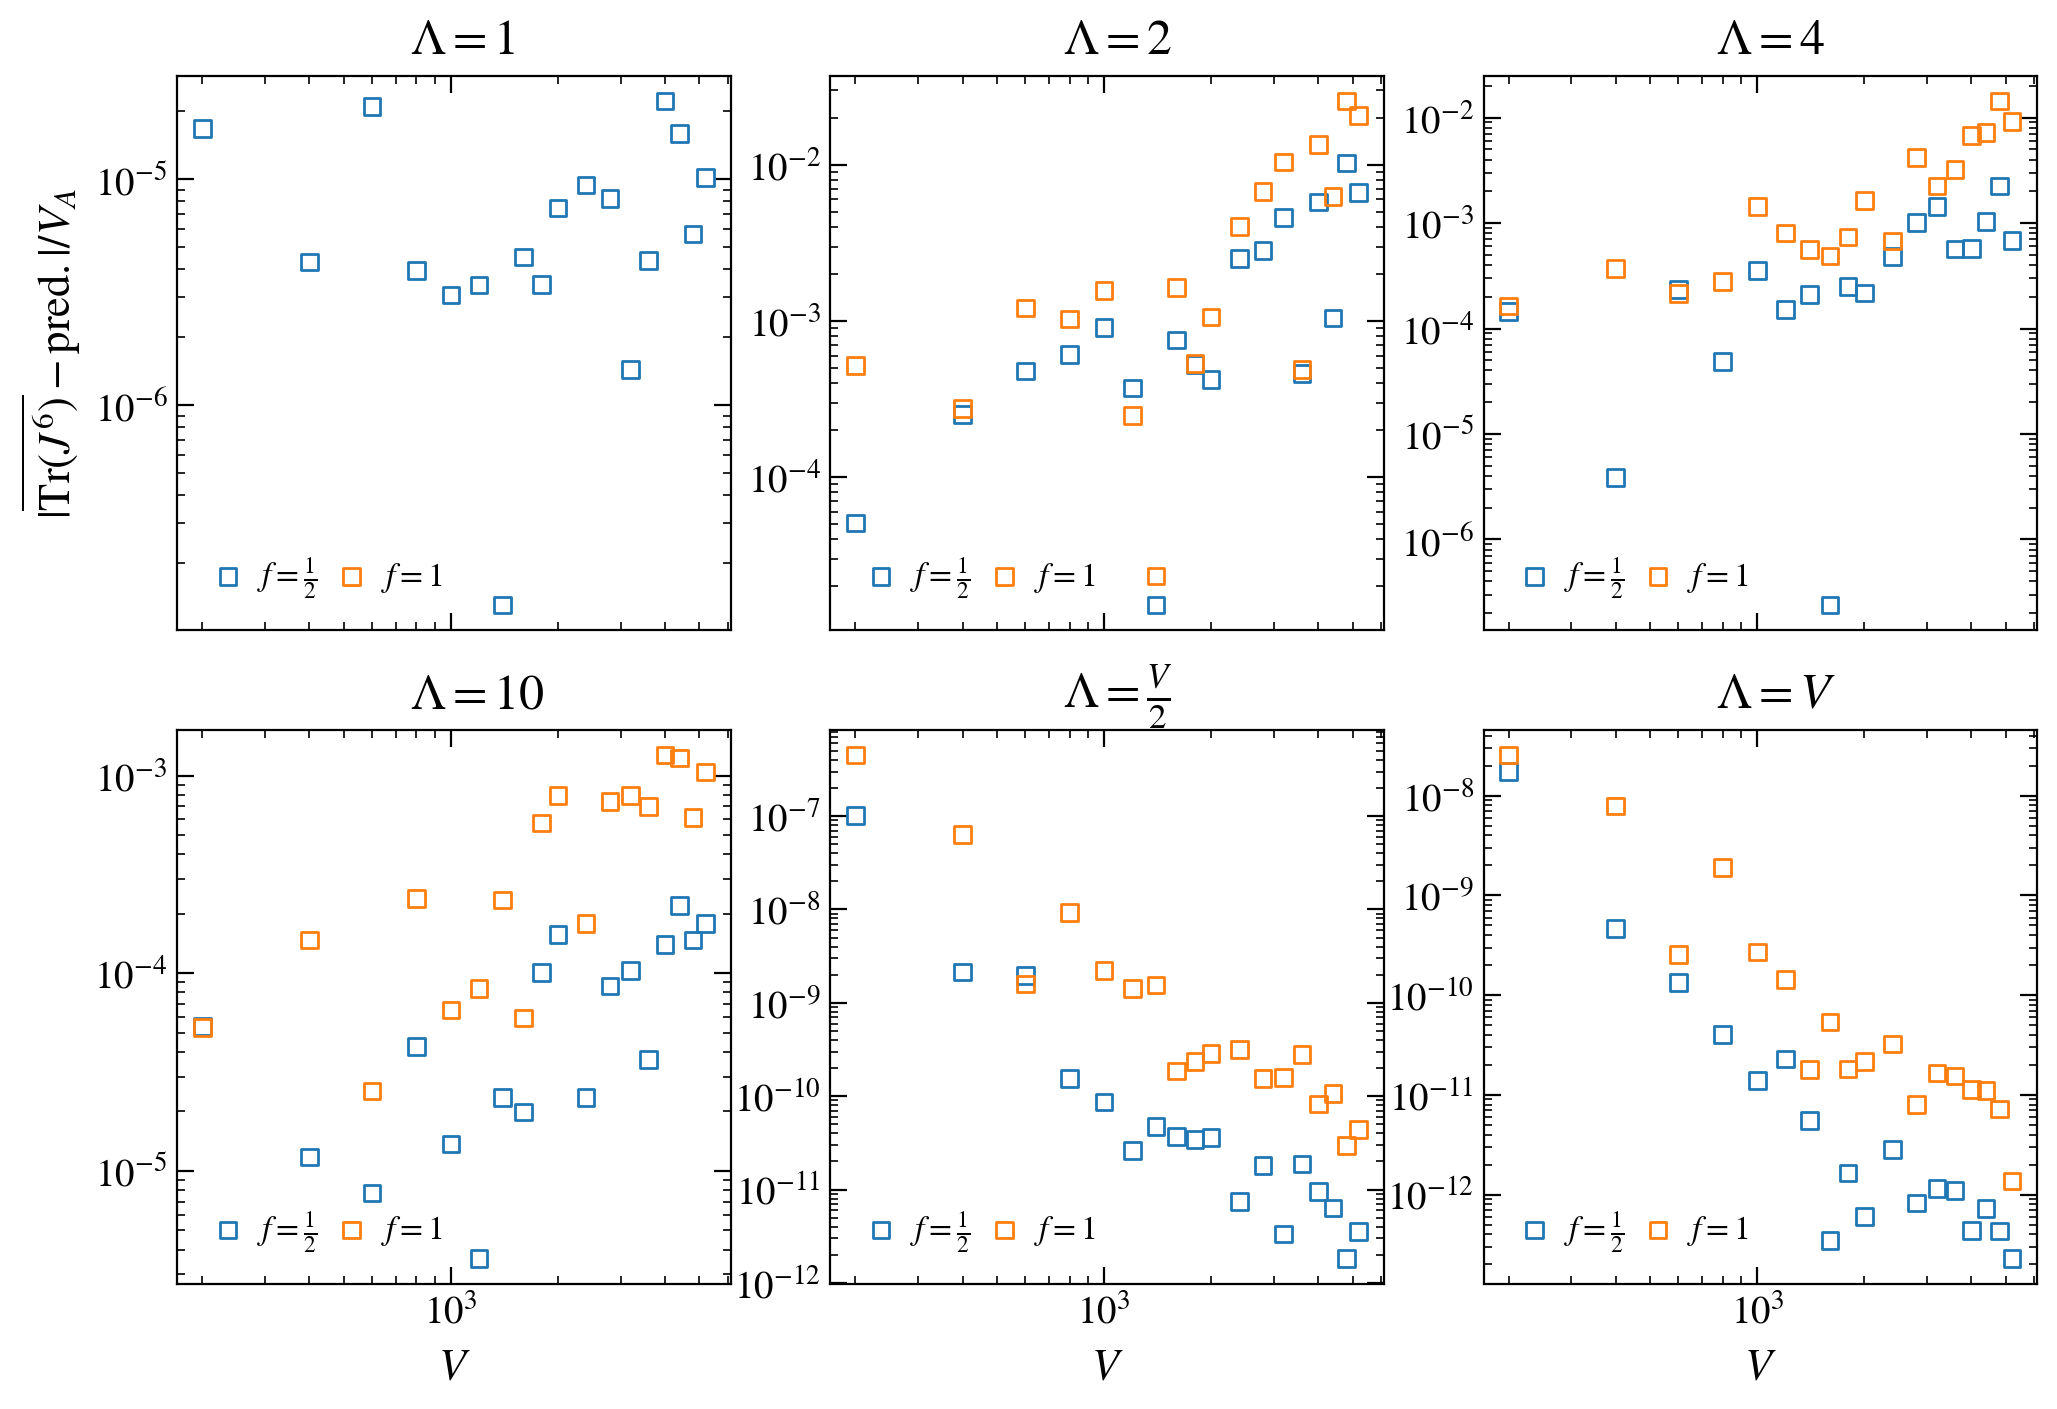

In [970]:
fig, axis = plt.subplots( nrows=2, ncols=3, figsize=(12,8), dpi = 200, sharex=True, sharey=False)
axis = axis.flatten()
colors_ls_cyc = itertools.cycle(colors_ls)
L = 100
w = 1
J = 1
g = 0.618


L=24
V=L

op = 1
ensemble = 'GUE'

prefix = base_dir(model='SYK2', d=1, ensemble=ensemble) + 'Entropy/NonGaussianity/'
prefix += "RandomChoice/"
if op == 1:   prefix += "SameHamiltonian/"
else:          prefix += "DifferentHamiltonian/"
    
# print(name)

# sizes = np.array([100, *np.arange(200, 1700, 200)]) if op else np.arange(16, 41, 4)
sizes = np.array( [*np.arange(200, 1801, 200), *np.arange(2000, 5301, 400)] )
norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes) )


# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])


order = 3

names = [r"$\Lambda=1$",r"$\Lambda=2$",r"$\Lambda=3$",r"$\Lambda=4$",r"$\Lambda=10$",r"$\Lambda=20$", r"$\Lambda=\frac{V}{2}$", r"$\Lambda=V$"]
indices = [0, 1, 3, 4, 6, 7]

for id, ii in enumerate(indices):
    nam = names[ii]
    colors_ls_cyc = itertools.cycle(colors_ls)
    # for iif, f in enumerate([1/4, 1/2, 1]):
    for iif, f in enumerate([1/2,1]):
        
        col = next(colors_ls_cyc)

        error = np.zeros(sizes.shape)
        # Gam = np.zeros(sizes.shape)
        for id_L, L in enumerate(sizes):
            V = L
            VA = int( V * f )
            name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
            # print(name)
            if exists(name):
                with h5py.File(name, "r") as file:
                    R = np.array(file.get('realisations'))
                    print(id, id_L, R)
                    gams = np.array(file.get('Gammas'))
                    subsystem = np.array(file.get('subsystem_sizes'))
                    idx = np.argmin(np.abs(subsystem - VA)) if f < 1 else subsystem.size
                    # print(VA, subsystem[idx])
                    G = gams[ii]
                    error[id_L] = np.abs( np.array(file.get('Trace n=%d'%order))[idx, ii] - Trace2n(VA=VA, f=f, x=G, n=order, ens=(ensemble == 'GUE')) ) / VA # / (VA * QC_terms(f, order))# * G / VA
            else:
                print(name)

        axis[id].scatter(sizes, error, marker='s', color=col, facecolor='None', label=r"$f=\frac{1}{%d}$"%(1/f) if f < 1 else r"$f=1$")
        print(G, f, error)
        def prob_fit(V, a, b):
            return a * np.exp(-b * V)
                                
        sizes = sizes[~np.isnan(error)]
        error = error[~np.isnan(error)]
        # if TD.size > 2:
        #     # print(iif, G, TD)
        #     pars, pconv= fit(prob_fit,
        #                     xdata = sizes,
        #                     ydata = TD,
        #                     maxfev = 20000)
        #     print(ii, f, *pars)
        #     z = np.linspace(min(sizes)-0.5, max(sizes)+0.5, 1000)
        #     axis[id].plot(z, prob_fit(z, *pars), color=col, lw=2, alpha=0.5)
        
        # axis.plot(1/sizes, Gamma(G) / ( binom(sizes,sizes//2) / (sizes**2 / 4 + 1) )**(G-1), color=col, lw=2, alpha=0.5)

    fig_help.set_plot_elements(axis[id], ylabel=r"$\left|\overline{{\rm Tr}(J^{%d})}-{\rm pred.}\right|/V_A$"%(2*order) if id==0 else "", xlabel=r"$V$" if id > 2 else "", font_size=14, set_legend=True, xscale='log', yscale='log')
    axis[id].legend(loc = 'lower left', ncol=3, columnspacing=0.4, frameon=False, fontsize=12, handletextpad=0.25, handlelength = 1.25)
    # axis.set_xlim(0, None)
    axis[id].annotate(names[indices[id]], fontsize=18, xy=(0.42, 1.04), xycoords='axes fraction')

# axis[0].annotate(r"(a) " + names[indices[0]], fontsize=18, xy=(0.42, 1.02), xycoords='axes fraction')
# axis[1].annotate(r"(b) " + names[indices[1]], fontsize=18, xy=(0.42, 1.02), xycoords='axes fraction')
# axis[2].annotate(r"(c) " + names[indices[2]], fontsize=18, xy=(0.42, 1.02), xycoords='axes fraction')
# fig_help.set_plot_elements(ax_inset, ylabel=r"${\bar{S}_A} / \ln2$", xlabel=r"$W$", font_size=14, set_legend=False, xlim=(8.0, 25.0), ylim=(0.7, 1.0))

fig.subplots_adjust(wspace = 0.18, hspace=0.18)

# \Lambda = D^\zeta, \zeta\in(0,1)

# add variances

In [ ]:
fig, axis = plt.subplots( nrows=1, ncols=3, figsize=(12,4), dpi = 200, sharex=True, sharey=True)
axis = axis.flatten()
colors_ls_cyc = itertools.cycle(colors_ls)
L = 100
w = 1
J = 1
g = 0.618


L=24
V=L
op = 0
ensemble = 'GUE'

prefix = base_dir(model='SYK2', d=1, ensemble=ensemble) + 'Entropy/NonGaussianity/'
prefix += "RandomChoice/"
if op == 1:   prefix += "SameHamiltonian/"
else:          prefix += "DifferentHamiltonian/"
    
# print(name)

sizes = np.arange(16, 49, 4)
# sizes = np.array([100, 200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800])

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes) )


# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])


order = 4

for iif, f in enumerate([1/4, 1/2, 1]):
    

    error = np.zeros(sizes.shape)
    # Gam = np.zeros(sizes.shape)
    for id_L, L in enumerate(sizes):
        V = L
        col = s_m.to_rgba(V)
        VA = int( V * f )
        name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
        # print(name)
        if exists(name):
            with h5py.File(name, "r") as file:
                gams = np.array(file.get('Gammas'))
                subsystem = np.array(file.get('subsystem_sizes'))
                idx = np.argmin(np.abs(subsystem - VA)) if f < 1 else subsystem.size
                error = np.array(file.get('Trace n=%d'%order))[idx, :]
                axis[iif].scatter(gams, error, marker='s', color=col, facecolor='None')
        else:
            print(name)

    fig_help.set_plot_elements(axis[iif], ylabel=r"$\overline{{\rm Tr}(J^{%d})}$"%(2*order) if iif==0 else "", xlabel=r"$\Lambda$", font_size=14, set_legend=True, xscale='log', yscale='log')
    axis[iif].legend(loc = 'lower left', ncol=3, columnspacing=0.4, frameon=False, fontsize=12, handletextpad=0.25, handlelength = 1.25)


axis[0].annotate(r"(a) $f=\frac{1}{4}$", fontsize=18, xy=(0.42, 1.02), xycoords='axes fraction')
axis[1].annotate(r"(b) $f=\frac{1}{2}$", fontsize=18, xy=(0.42, 1.02), xycoords='axes fraction')
axis[2].annotate(r"(c) $f=1$",           fontsize=18, xy=(0.42, 1.02), xycoords='axes fraction')
# fig_help.set_plot_elements(ax_inset, ylabel=r"${\bar{S}_A} / \ln2$", xlabel=r"$W$", font_size=14, set_legend=False, xlim=(8.0, 25.0), ylim=(0.7, 1.0))

fig.subplots_adjust(wspace = 0.05, hspace=0.15)

## SUBSYSTEM-SIZE DEPENDENCE OF CORRELATION MATRIX

In [736]:
sizes = np.arange(10, 23, 2)
# print( binom(sizes, sizes/2)**0.2)
print( 0.01*binom(sizes, sizes/2))
np.logspace(-2, 0, 11)

[2.52000e+00 9.24000e+00 3.43200e+01 1.28700e+02 4.86200e+02 1.84756e+03
 7.05432e+03]


array([0.01      , 0.01584893, 0.02511886, 0.03981072, 0.06309573,
       0.1       , 0.15848932, 0.25118864, 0.39810717, 0.63095734,
       1.        ])

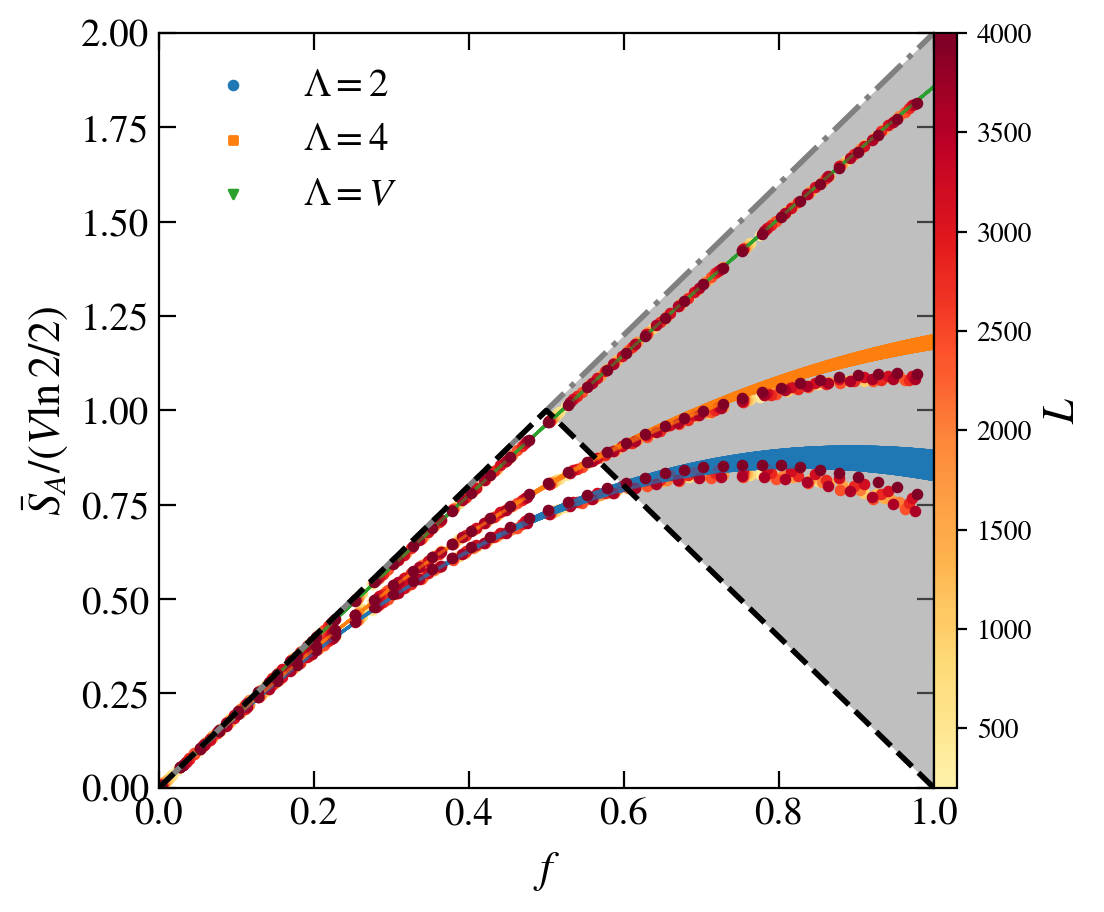

In [831]:
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)

ff = np.linspace(0, 1.0, 1000)
axis.plot(ff, 2*ff, ls='-.', color='gray', lw=2)
axis.plot(ff, 1 - 2*np.abs(0.5 - ff), ls='--', color='k', lw=2)
axis.fill_between(ff, 1 - 2*np.abs(0.5 - ff), 2*ff, color='gray', alpha=0.5, lw=0)

# ff = np.linspace(0., 0.5, 100)
# axis.plot(ff, 2 * ff * (1 - (1 + (1-ff)/ff * np.log(1-ff) ) / np.log(2)), ls=':', color='black')
# ff = np.linspace(.5, 1., 100)
# axis.plot(ff, 2 * (1-ff) * (1 - (1 + ff/(1-ff) * np.log(ff) ) / np.log(2)), ls=':', color='black')    

colors_ls_cyc = itertools.cycle(colors_ls)
markers = itertools.cycle(markers_ls)
markers
L = 100
w = 1
J = 1
g = 0.618


L=2000
V=L
op = 1
ensemble = 'GUE'

prefix = base_dir(model='SYK2', d=1, ensemble=ensemble) + 'Entropy/NonGaussianity/'
# if op == 2:   prefix += "AllStates/"
# else:         prefix += "RandomChoice/"
prefix += "RandomChoice/"
if op == 1:   prefix += "SameHamiltonian/"
else:         prefix += "DifferentHamiltonian/"


order = 3

sizes = np.array( [*np.arange(200, 1801, 200), *np.arange(2000, 4101, 400)] )
norm = matplotlib.colors.Normalize(
                vmin=min(sizes),
                vmax=max(sizes) )


# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
# s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])
markers = itertools.cycle(markers_ls)

# Gammas = np.array([1, 2, 4, 10, V//2, V, 2*V, int(V*np.log(V))]) if V < 26 else np.array([1, 2, 4, 10, V//2, V])
names = [r"$\Lambda=1$",r"$\Lambda=2$",r"$\Lambda=4$",r"$\Lambda=10$", r"$\Lambda=\frac{V}{2}$", r"$\Lambda=V$", r"$\Lambda=2V$", r"$\Lambda=V\ln{V}$"]
indices = [1, 2, 5]
for ii in indices:
    mar = next(markers)
    nam = names[ii]
    axis.scatter(np.nan, np.nan, marker = mar, color=next(colors_ls_cyc), s=10, label=nam)

for L in sizes:
    markers = itertools.cycle(markers_ls)
    colors_ls_cyc = itertools.cycle(colors_ls)
    V = L
    col = s_m.to_rgba(L)
    name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
    # print(name)
    if exists(name):
        with h5py.File(name, "r") as file:
            subsizes = np.array(file.get('subsystem_sizes'))
            Gammas = np.array(file.get('Gammas'))
            S = np.zeros((subsizes.size+1, Gammas.size))
            S[:-1, :] = np.array(file.get('entropy_corr_mat')) / (V//2*np.log(2))
            S[-1, :] = np.array(file.get('Non-Gaussianity')) / (V//2*np.log(2))
    else:
        print(name)    

    subsizes = np.array([*subsizes, V])
    
    for ii in indices:
        nam = names[ii]
        gam = Gammas[ii]
        col2 = next(colors_ls_cyc)
        mar = next(markers)

        ff = np.linspace(0, 1, 1000)
        # axis.plot(ff, 2 * ff * s_QCQ(ff, gam), ls='--', color=col, lw=0.75)
        axis.fill_between(ff, 2*ff*QC_lower_bound(f=ff, x=gam, n=order), 2*ff*QC_upper_bound(f=ff, x=gam, n=order), alpha=0.5, color=col2)
        axis.scatter(subsizes[::10] / L, S[::10, ii], marker = 'o', color=col, s=10)
    
fig_help.set_plot_elements(axis, ylabel=r"${\bar{S}_A} / (V\ln2/2)$", xlabel=r"$f$", font_size=14, set_legend=True, xlim=(0,1), ylim=(0,2), xscale='linear', yscale='linear')

cbaxes = axis.inset_axes([1., 0.0, 0.03, 1])
cbar = fig.colorbar(s_m, cax = cbaxes, orientation='vertical')
cbar.set_label(r"$L$", fontsize=16)


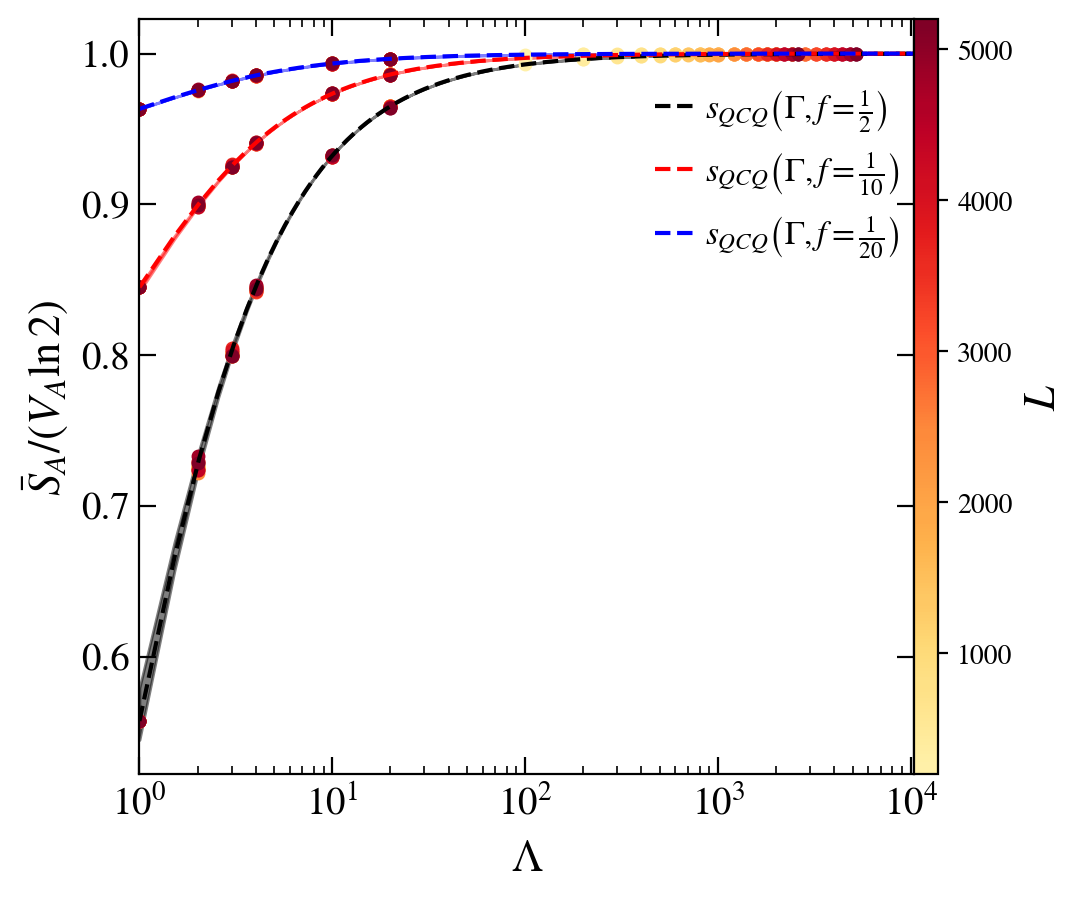

In [980]:
L = 100
w = 1
J = 1
g = 0.618



fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)
# fig, axis_flu

op=1

ensemble = 'GUE'

def _get_prefix(_op, ens = 'GOE'):
    prefix = base_dir(model='SYK2', d=1, ensemble=ens) + 'Entropy/NonGaussianity/'
    prefix += "RandomChoice/"
    if _op == 1:   prefix += "SameHamiltonian/"
    else:          prefix += "DifferentHamiltonian/"
    return prefix

prefix = _get_prefix(op, ens=ensemble)
# ax_inset = fig_help.add_subplot_axes(axis, fig, [0.5, 0.5, 0.46, 0.46])

colors_ls_cyc = itertools.cycle(colors_ls)


# sizes = np.array([100, 200, 500, 1000])

sizes = np.array( [*np.arange(200, 1801, 200), *np.arange(2000, 5301, 400)] )

norm = matplotlib.colors.Normalize(
                vmin=min(sizes),
                vmax=max(sizes) )


# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
# s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

subsize_idx = -1

names = [r"$f=\frac{1}{6}$", r"$f=\frac{1}{4}$", r"$f=\frac{1}{2}$", r"$f=\frac{1}{2}$"]
fracs = [1/20, 1/10, 1/5, 1/4, 1/2]

for subsize_idx in [0, 2, 4]:
    colors_ls_cyc = itertools.cycle(colors_ls)
    for id_L, L in enumerate(sizes):
        V = L
        VA = int(fracs[subsize_idx] * V)
        col = next(colors_ls_cyc)

        name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
        # print(name)
        if exists(name):
            with h5py.File(name, "r") as file:
                subsystem = np.array(file.get('subsystem_sizes'))
                idx = np.argmin( np.abs(subsystem - VA) )
                S = np.array(file.get('entropy_corr_mat'))[idx, :] / (VA * np.log(2))
                xx = np.array(file.get('Gammas'))
                axis.plot(xx, S, marker='o', markersize=4, color=s_m.to_rgba(L), lw=0)
        else:
            print(name)
        # ax_inset.plot(4 * w_vals, ydata, marker='o', markersize=4, label=r"$L=%d$"%(L))
        # axis.axhline(y = 1 - 1. / (V*np.log(2)), color=col, ls='--')


order = 3

gams = np.linspace(1, 2*max(sizes), 20000)
axis.plot(gams, s_QCQ(1/2, gams), ls='--', color='k', label=r'$s_{QCQ}\left(\Gamma,f=\frac{1}{2}\right)$')
ff=1/2
axis.fill_between(gams, QC_lower_bound(f=ff, x=gams, n=order), QC_upper_bound(f=ff, x=gams, n=order), alpha=0.5, color='k')

axis.plot(gams, s_QCQ(1/5, gams), ls='--', color='red', label=r'$s_{QCQ}\left(\Gamma,f=\frac{1}{10}\right)$')
ff=1/5
axis.fill_between(gams, QC_lower_bound(f=ff, x=gams, n=order), QC_upper_bound(f=ff, x=gams, n=order), alpha=0.5, color='red')

axis.plot(gams, s_QCQ(1/20, gams), ls='--', color='blue', label=r'$s_{QCQ}\left(\Gamma,f=\frac{1}{20}\right)$')
ff=1/20
axis.fill_between(gams, QC_lower_bound(f=ff, x=gams, n=order), QC_upper_bound(f=ff, x=gams, n=order), alpha=0.5, color='blue')

# axis.annotate(r"$f=\frac{1}{2}$", xy=(1.3, 0.55), fontsize=14, rotation=0)
# axis.annotate(r"$f=\frac{1}{4}$", xy=(1.3, 0.8), fontsize=14, rotation=0)
# axis.annotate(r"$f=\frac{1}{6}$", xy=(1.3, 0.93), fontsize=14, rotation=0)

fig_help.set_plot_elements(axis, ylabel=r"${\bar{S}_A} / (V_A\ln2)$", xlabel=r"$\Lambda$", font_size=14, set_legend=True, xscale='log', yscale='linear')
axis.legend(loc = 'upper right', columnspacing=0.4, frameon=False, fontsize=12, handletextpad=0.25, handlelength = 1.25, bbox_to_anchor=(1.02,0.95))
axis.set_xlim(1, 2*max(sizes))
# axis.set_ylim(0.51, 1)

# axis.set_title(r"SYK$2$", fontsize=16)
# fig_help.set_plot_elements(ax_inset, ylabel=r"${\bar{S}_A} / \ln2$", xlabel=r"$W$", font_size=14, set_legend=False, xlim=(8.0, 25.0), ylim=(0.7, 1.0))

fig.subplots_adjust(wspace = 0.3, hspace=0.05)
cbaxes = axis.inset_axes([1., 0.0, 0.03, 1])
cbar = fig.colorbar(s_m, cax = cbaxes, orientation='vertical')
cbar.set_label(r"$L$", fontsize=16)

## PURITY AND NON-GAUSSIANITY

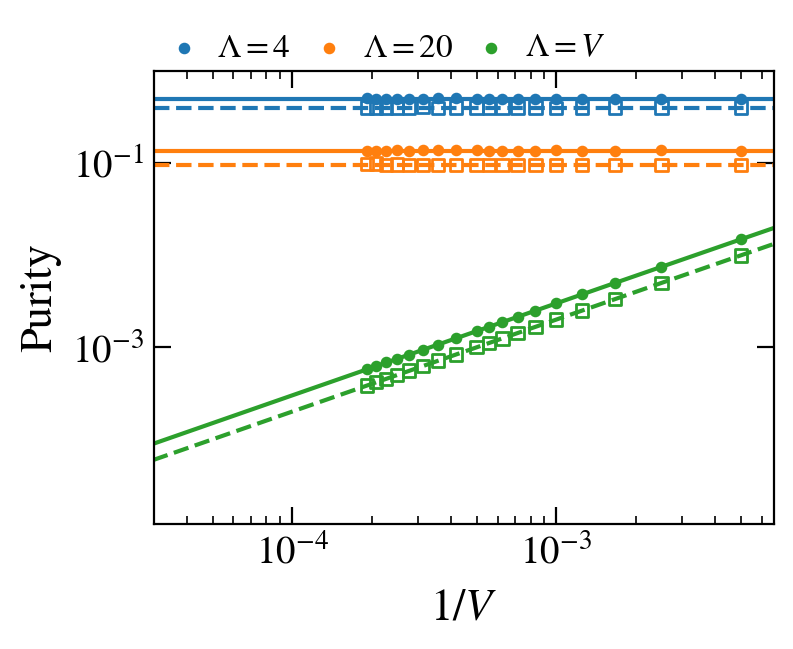

In [14]:
L = 100
w = 1
J = 1
g = 0.618



fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex = True)
# fig, axis_flu

op=1

ensemble = 'GOE'

def _get_prefix(_op, ens = 'GOE'):
    prefix = base_dir(model='SYK2', d=1, ensemble=ens) + 'Entropy/NonGaussianity/'
    prefix += "RandomChoice/"
    if _op == 1:   prefix += "SameHamiltonian/"
    else:          prefix += "DifferentHamiltonian/"
    return prefix

prefix = _get_prefix(op)

colors_ls_cyc = itertools.cycle(colors_ls)
sizes = np.arange(12, 31, 2)

subsize_idx = -1

names = [r"$\Lambda=1$",r"$\Lambda=2$",r"$\Lambda=3$",r"$\Lambda=4$", r"$\Lambda=10$", r"$\Lambda=20$", r"$\Lambda=\frac{V}{2}$", r"$\Lambda=V$"]
indices = [3, 5, 7]
colors_ls_cyc = itertools.cycle(colors_ls)
for ii in indices:
    nam = names[ii]
    sizes = np.array( [*np.arange(200, 1801, 200), *np.arange(2000, 5301, 400)] )
    col = next(colors_ls_cyc)

    prefix = _get_prefix(1, 'GOE')
    S_op0 = np.zeros(sizes.shape)
    for id_L, L in enumerate(sizes):
        V = L
        name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
        # print(name)
        if exists(name):
            with h5py.File(name, "r") as file:
                gams = np.array(file.get('Gammas'))
                subsystem = np.array(file.get('subsystem_sizes'))
                idx = np.argmin( np.abs(subsystem - V//2) )
                # ent = np.array(file.get('entropy'))
                P = np.array(file.get('Purity2'))
                S_op0[id_L] = P[ii] / (L)
        else:
            print(name)
    
    axis.scatter(1/sizes, S_op0, marker='o', s=10, color=col, facecolor=col, label=r"%s"%(nam))
    
    prefix = _get_prefix(1, 'GUE')
    S_op1 = np.zeros(sizes.shape)
    Gamss = np.zeros(sizes.shape)
    for id_L, L in enumerate(sizes):
        V = L
        name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
        # print(name)
        if exists(name):
            with h5py.File(name, "r") as file:
                gams = np.array(file.get('Gammas'))
                subsystem = np.array(file.get('subsystem_sizes'))
                idx = np.argmin( np.abs(subsystem - V//2) )
                P = np.array(file.get('Purity2'))
                S_op1[id_L] = P[ii] / (L)
                Gamss[ii] = gams[ii]
                G = gams[ii]
        else:
            print(name)
    axis.scatter(1/sizes, S_op1, marker='s', s=20, color=col, facecolor='None')
    # axis.plot(1/sizes, A2(VA=1, f=1, x=Gamss, ens=0), color=col, ls='-')
    # axis.plot(1/sizes, A2(VA=1, f=1, x=Gamss, ens=1), color=col, ls='--')
    # print(ii)
    if ii < 6:
        axis.axhline(y=A2(VA=1, f=1, x=G, ens=0), color=col, ls='-')
        axis.axhline(y=A2(VA=1, f=1, x=G, ens=1), color=col, ls='--')
    elif ii == 6:
        x = np.linspace(1e-5, 1/150, 1000)
        axis.plot(x, A2(VA=1, f=1, x=1/x/2, ens=0), color=col, ls='-')
        axis.plot(x, A2(VA=1, f=1, x=1/x/2, ens=1), color=col, ls='--')
    elif ii == 7:
        x = np.linspace(1e-5, 1/150, 1000)
        # print(A2(VA=1, f=1, x=1/x, ens=0))
        axis.plot(x, A2(VA=1, f=1, x=1/x, ens=0), color=col, ls='-')
        axis.plot(x, A2(VA=1, f=1, x=1/x, ens=1), color=col, ls='--')
    else:
        print("Shit")
    # axis[1].scatter(1/sizes, np.abs(S_op0 - S_op1), marker='v', s=10, color=col, facecolor=col, label=r"%s"%(nam))

fig_help.set_plot_elements(axis, ylabel=r"Purity", xlabel = r"$1/V$", font_size=14, set_legend=True, xlim=(3e-5, 1/150), ylim=(0.0,1), xscale='log', yscale='log')
fig_help.set_legend(axis, fontsize=12, loc = 'upper left', ncol=4, columnspacing=0.4, frameon=False, anchor=(-0.04, 1.15))

# fig_help.set_plot_elements(axis[1], ylabel=r"$|\overline{P}^{\rm GOE} - \overline{P}^{\rm GUE}|$", xlabel=r"$1/V$", font_size=14, set_legend=True, xscale='log', yscale='log')
# axis[1].legend(loc = 'upper left', ncol=1, columnspacing=0.4, frameon=False, fontsize=12, handletextpad=0.25, handlelength = 1.25)


# fig_help.set_plot_elements(ax_inset, ylabel=r"${\bar{S}_A} / \ln2$", xlabel=r"$W$", font_size=14, set_legend=False, xlim=(8.0, 25.0), ylim=(0.7, 1.0))

fig.subplots_adjust(wspace = 0.3, hspace=0.05)


2 0.33360522226704714
4 0.573189478852042
20 0.8950663449021731


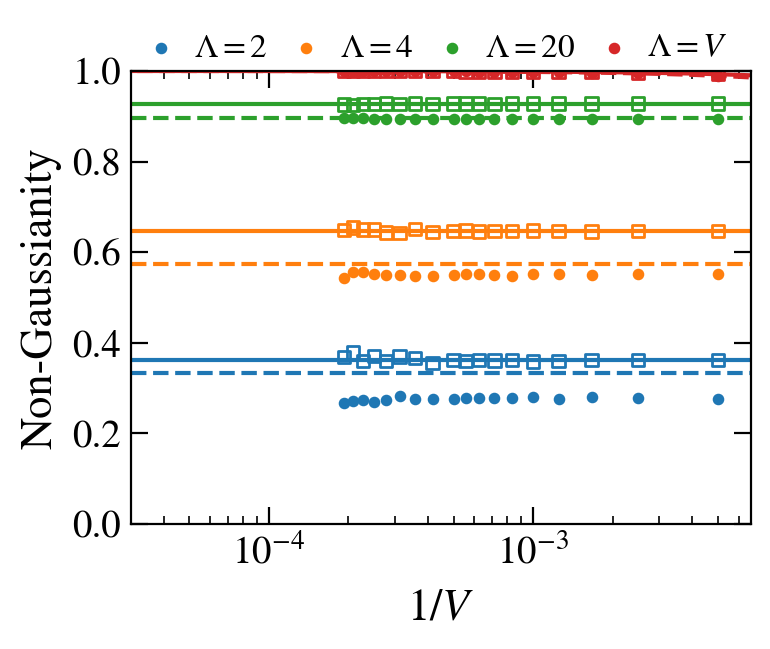

In [15]:
L = 100
w = 1
J = 1
g = 0.618



fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex = True)
# fig, axis_flu

op=1

ensemble = 'GOE'

def _get_prefix(_op, ens = 'GOE'):
    prefix = base_dir(model='SYK2', d=1, ensemble=ens) + 'Entropy/NonGaussianity/'
    prefix += "RandomChoice/"
    if _op == 1:   prefix += "SameHamiltonian/"
    else:          prefix += "DifferentHamiltonian/"
    return prefix

prefix = _get_prefix(op)

colors_ls_cyc = itertools.cycle(colors_ls)
sizes = np.arange(12, 31, 2)

subsize_idx = -1

names = [r"$\Lambda=1$",r"$\Lambda=2$",r"$\Lambda=3$",r"$\Lambda=4$", r"$\Lambda=10$", r"$\Lambda=20$", r"$\Lambda=\frac{V}{2}$", r"$\Lambda=V$"]
indices = [1, 3, 5, 7]
colors_ls_cyc = itertools.cycle(colors_ls)
for ii in indices:
    nam = names[ii]
    sizes = np.array( [*np.arange(200, 1801, 200), *np.arange(2000, 5301, 400)] )
    col = next(colors_ls_cyc)

    prefix = _get_prefix(1, 'GOE')
    S_op0 = np.zeros(sizes.shape)
    for id_L, L in enumerate(sizes):
        V = L
        name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
        # print(name)
        if exists(name):
            with h5py.File(name, "r") as file:
                gams = np.array(file.get('Gammas'))
                subsystem = np.array(file.get('subsystem_sizes'))
                idx = np.argmin( np.abs(subsystem - V//2) )
                # ent = np.array(file.get('entropy'))
                NG = np.array(file.get('Non-Gaussianity'))
                S_op0[id_L] = NG[ii] / (L * np.log(2))
        else:
            print(name)
    
    axis.scatter(1/sizes, S_op0, marker='o', s=10, color=col, facecolor=col, label=r"%s"%(nam))
    
    prefix = _get_prefix(1, 'GUE')
    S_op1 = np.zeros(sizes.shape)
    Gamss = np.zeros(sizes.shape)
    for id_L, L in enumerate(sizes):
        V = L
        name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
        # print(name)
        if exists(name):
            with h5py.File(name, "r") as file:
                gams = np.array(file.get('Gammas'))
                subsystem = np.array(file.get('subsystem_sizes'))
                idx = np.argmin( np.abs(subsystem - V//2) )
                NG = np.array(file.get('Non-Gaussianity'))
                S_op1[id_L] = NG[ii] / (L * np.log(2))
                Gamss[ii] = gams[ii]
                G = gams[ii]
        else:
            print(name)
    axis.scatter(1/sizes, S_op1, marker='s', s=20, color=col, facecolor='None')
    # axis.plot(1/sizes, A2(VA=1, f=1, x=Gamss, ens=0), color=col, ls='-')
    # axis.plot(1/sizes, A2(VA=1, f=1, x=Gamss, ens=1), color=col, ls='--')
    # print(ii)
    if ii < 6:
        print(G, NonGaussianity(x=G, n=4, ens=0))
        axis.axhline(y=NonGaussianity(x=G, n=80), color=col, ls='-')
        axis.axhline(y=NonGaussianity(x=G, n=4, ens=0), color=col, ls='--')
    elif ii == 6:
        x = np.linspace(1e-5, 1/150, 1000)
        axis.plot(x, NonGaussianity(x=1/x/2, n=10), color=col, ls='-')
        axis.plot(x, NonGaussianity(x=1/x/2, n=3, ens=0), color=col, ls='--')
    elif ii == 7:
        x = np.linspace(1e-5, 1/150, 100)
        axis.plot(x, NonGaussianity(x=1/x, n=10), color=col, ls='-')
        axis.plot(x, NonGaussianity(x=1/x, n=3, ens=0), color=col, ls='--')
    else:
        print("Shit")
    # axis[1].scatter(1/sizes, np.abs(S_op0 - S_op1), marker='v', s=10, color=col, facecolor=col, label=r"%s"%(nam))

fig_help.set_plot_elements(axis, ylabel=r"Non-Gaussianity", xlabel = r"$1/V$", font_size=14, set_legend=True, xlim=(3e-5, 1/150), ylim=(0.0,1.0), xscale='log', yscale='linear')
fig_help.set_legend(axis, fontsize=12, loc = 'upper left', ncol=4, columnspacing=0.4, frameon=False, anchor=(-0.04, 1.15))

axis.scatter(np.nan, np.nan, marker='o', s=10, color=col, facecolor=col, label=r"GOE")
axis.scatter(np.nan, np.nan, marker='s', s=20, color=col, facecolor='None', label=r"GUE")
# fig_help.set_plot_elements(axis[1], ylabel=r"$|\overline{P}^{\rm GOE} - \overline{P}^{\rm GUE}|$", xlabel=r"$1/V$", font_size=14, set_legend=True, xscale='log', yscale='log')
# axis[1].legend(loc = 'upper left', ncol=1, columnspacing=0.4, frameon=False, fontsize=12, handletextpad=0.25, handlelength = 1.25)


# fig_help.set_plot_elements(ax_inset, ylabel=r"${\bar{S}_A} / \ln2$", xlabel=r"$W$", font_size=14, set_legend=False, xlim=(8.0, 25.0), ylim=(0.7, 1.0))

fig.subplots_adjust(wspace = 0.3, hspace=0.05)


$\Lambda=1$ 1.4348386000456532
$\Lambda=2$ 1.0855601907223267
$\Lambda=4$ 0.8618623209872711
$\Lambda=\frac{V}{2}$ 0.36028366056815686
$\Lambda=V$ 0.19601426337435293
83.33333333333333


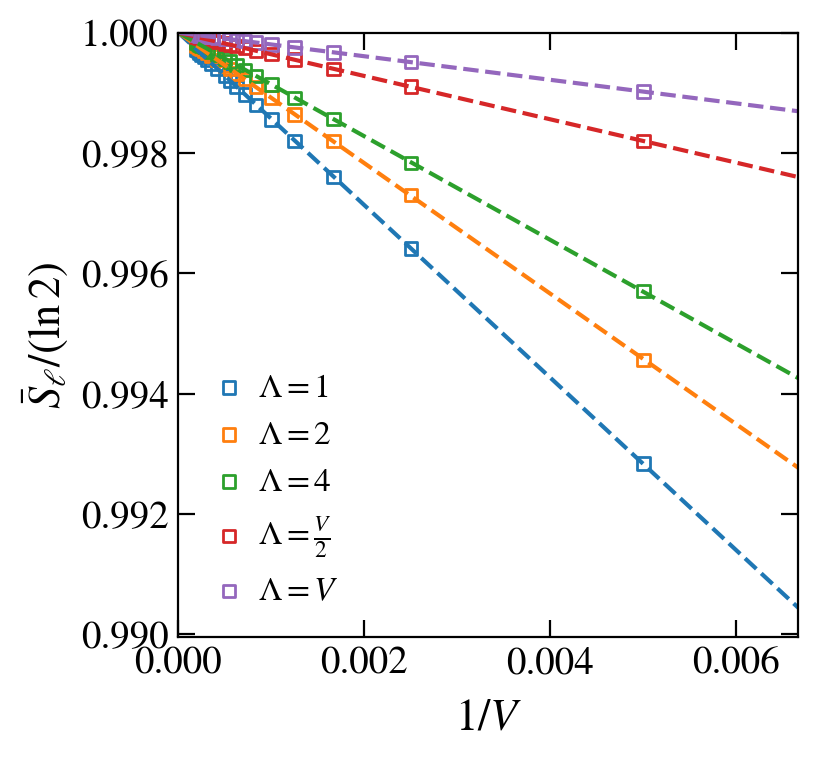

In [982]:
L = 100
w = 1
J = 1
g = 0.618



fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,4), dpi = 200)
# fig, axis_flu

op = 1

ensemble = 'GOE'

def _get_prefix(_op):
    prefix = base_dir(model='SYK2', d=1, ensemble=ensemble) + 'Entropy/NonGaussianity/'
    prefix += "RandomChoice/"
    if _op == 1:   prefix += "SameHamiltonian/"
    else:          prefix += "DifferentHamiltonian/"
    return prefix

prefix = _get_prefix(op)

colors_ls_cyc = itertools.cycle(colors_ls)

f = 0

names = [r"$\Lambda=1$",r"$\Lambda=2$",r"$\Lambda=4$",r"$\Lambda=10$", r"$\Lambda=\frac{V}{2}$", r"$\Lambda=V$", r"$\Lambda=2V$", r"$\Lambda=V\ln{V}$"]
indices = [0, 1, 2, 4, 5]
colors_ls_cyc = itertools.cycle(colors_ls)
for ii in indices:
    nam = names[ii]
    sizes = np.array( [*np.arange(200, 1801, 200), *np.arange(2000, 5301, 400)] )
    col = next(colors_ls_cyc)
    
    S = np.zeros(sizes.shape)
    S_corr = np.zeros(sizes.shape)
    for id_L, L in enumerate(sizes):
        V = L
        VA = int( V * f ) if f > 0 else 1
        name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
        # print(name)
        if exists(name):
            with h5py.File(name, "r") as file:
                gams = np.array(file.get('Gammas'))
                
                subsystem = np.array(file.get('subsystem_sizes'))
                idx = np.argmin( np.abs(subsystem - VA) )
                
                if f > 0:
                    ent = np.array(file.get('entropy_corr_mat'))[idx, ii]
                    S_corr[id_L] = ent / (VA * np.log(2))
                else:
                    ent = np.mean(np.array(file.get('entropy_single_site_corr_mat')), axis=0)
                    S_corr[id_L] = ent[ii] / (np.log(2))
        else:
            print(name)

    # axis.scatter(1/sizes, S, marker='o', s=10, color=col, facecolor=col, label=r"%s"%(nam))
    axis.scatter(1/sizes, S_corr, marker='s', s=20, color=col, facecolor='None', label=r"%s"%(nam))

    def lin_fitt(x, a):
        return 1 - a * x
    pars, pconv= fit(lin_fitt,
                xdata = 1/sizes,
                ydata = S_corr,
                maxfev = 20000)
    z = np.linspace(0, 1/150, 10000)
    axis.plot(z, lin_fitt(z, *pars), ls='--', color=col)
    print(nam, pars[0])
    
fig_help.set_plot_elements(axis, ylabel=r"${\bar{S}_A} / (V_A\ln2)$" if f > 0 else r"${\bar{S}_\ell} / (\ln2)$", xlabel=r"$1/V$", font_size=14, set_legend=True, xlim=(0, 1/150), ylim=(None, 1), xscale='linear', yscale='linear')
axis.legend(loc = 'lower left', ncol=1, columnspacing=0.4, frameon=False, fontsize=12, handletextpad=0.25, handlelength = 1.25)
axis.set_ylim(None, 1)

# fig_help.set_plot_elements(ax_inset, ylabel=r"${\bar{S}_A} / \ln2$", xlabel=r"$W$", font_size=14, set_legend=False, xlim=(8.0, 25.0), ylim=(0.7, 1.0))

fig.subplots_adjust(wspace = 0.3, hspace=0.05)

# V**2, V**3, 2**(V/2)
print(30 * 10000 / 3600)

## MANY-BODY ENTANGLEMENT CALCULATION

Text(0.5, 1.0, '$L=28$')

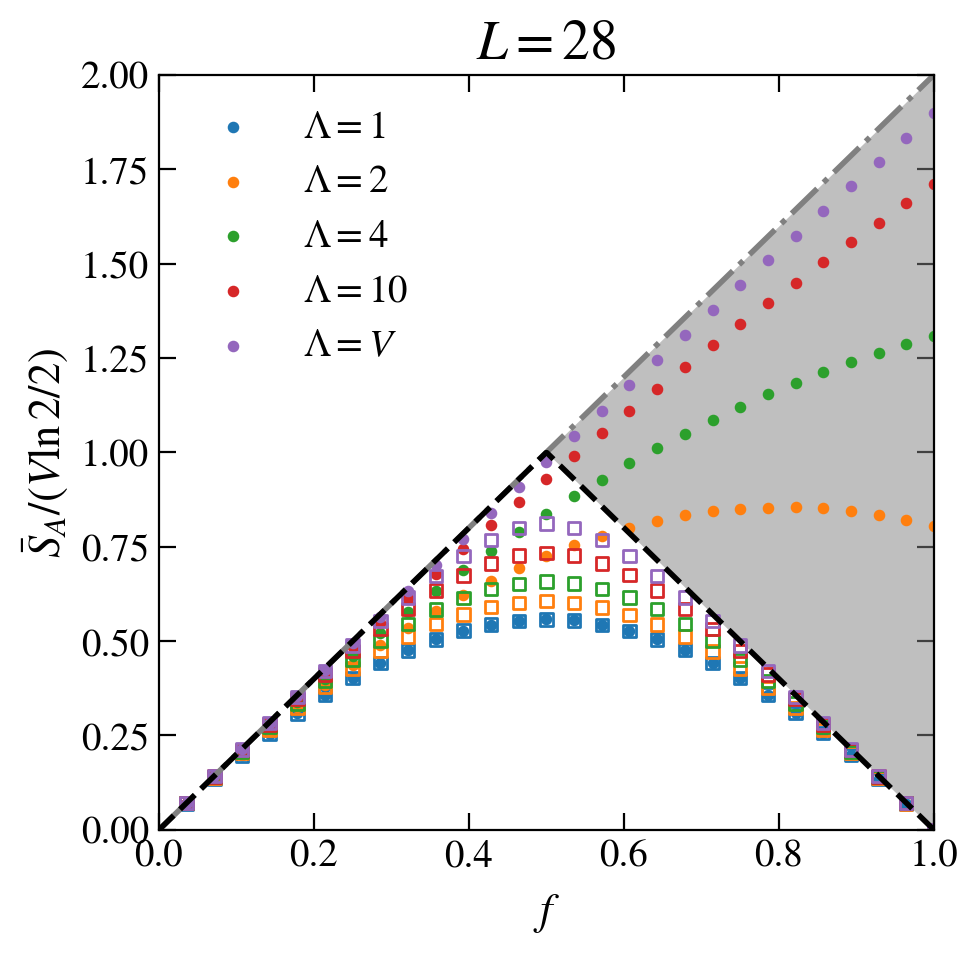

In [749]:
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)

ff = np.linspace(0, 1.0, 1000)
axis.plot(ff, 2*ff, ls='-.', color='gray', lw=2)
axis.plot(ff, 1 - 2*np.abs(0.5 - ff), ls='--', color='k', lw=2)
axis.fill_between(ff, 1 - 2*np.abs(0.5 - ff), 2*ff, color='gray', alpha=0.5, lw=0)

# ff = np.linspace(0., 0.5, 100)
# axis.plot(ff, 2 * ff * (1 - (1 + (1-ff)/ff * np.log(1-ff) ) / np.log(2)), ls=':', color='black')
# ff = np.linspace(.5, 1., 100)
# axis.plot(ff, 2 * (1-ff) * (1 - (1 + ff/(1-ff) * np.log(ff) ) / np.log(2)), ls=':', color='black')    

colors_ls_cyc = itertools.cycle(colors_ls)
L = 100
w = 1
J = 1
g = 0.618


L=28
V=L
op = 0
ensemble = 'GUE'

prefix = base_dir(model='SYK2', d=1, ensemble=ensemble) + 'Entropy/Degeneracy/'
# if op == 2:   prefix += "AllStates/"
# else:         prefix += "RandomChoice/"
prefix += "RandomChoice/"
if op == 1:   prefix += "SameHamiltonian/"
else:         prefix += "DifferentHamiltonian/"
    
name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
# print(name)

order = 3

if exists(name):
    with h5py.File(name, "r") as file:
        subsizes = np.array(file.get('subsystem_sizes'))
        Gammas = np.array(file.get('Gammas'))
        S = np.zeros((subsizes.size+1, Gammas.size))
        S[:-1, :] = np.array(file.get('entropy_corr_mat')) / (V//2*np.log(2))
        S[-1, :] = np.array(file.get('Non-Gaussianity')) / (V//2*np.log(2))
        # print(S)
        Sent = np.zeros((subsizes.size+1, Gammas.size))
        Sent[:-1,:] = np.array(file.get('entropy')) / (V//2*np.log(2))
        Sent[-1, :] = np.zeros((Gammas.size))

subsizes = np.array([*subsizes, V])
# print(S)

# Gammas = np.array([1, 2, 4, 10, V//2, V, 2*V, int(V*np.log(V))]) if V < 26 else np.array([1, 2, 4, 10, V//2, V])
names = [r"$\Lambda=1$",r"$\Lambda=2$",r"$\Lambda=4$",r"$\Lambda=10$", r"$\Lambda=\frac{V}{2}$", r"$\Lambda=V$", r"$\Lambda=2V$", r"$\Lambda=V\ln{V}$"]
indices = [0, 1, 2, 3, 5]
colors_ls_cyc = itertools.cycle(colors_ls)
for ii in indices:
    nam = names[ii]
    gam = Gammas[ii]
    col = next(colors_ls_cyc)

    ff = np.linspace(0, 1, 1000)
    # axis.plot(ff, 2 * ff * s_QCQ(ff, gam), ls='--', color=col, lw=0.75)
    # axis.fill_between(ff, 2*ff*QC_lower_bound(f=ff, x=gam, n=order), 2*ff*QC_upper_bound(f=ff, x=gam, n=order), alpha=0.5, color=col)
    
    # print(2 * ff * ( 1 - (s_QCQ(ff, gam)) / (np.log(2)) ))
    
    # ff = np.linspace(0.5, 1.0, 100)
    # axis.plot(ff, 2*(1-ff)*s_QCQ(1-ff, gam), ls='-', color=col, lw=0.75)

    axis.scatter(subsizes / L, S[:, ii], marker = 'o', color=col, s=10, label=nam)
    axis.scatter(subsizes / L, Sent[:, ii], marker = 's', color=col, s=20, facecolor='None')
    # axis.scatter(1 - subsizes[::5] / L, S[::5,gam - 1], color=col, s=10, facecolor='None')
    # axis.axvline(x=np.sqrt(gam), ls=':', color=col)
    
fig_help.set_plot_elements(axis, ylabel=r"${\bar{S}_A} / (V\ln2/2)$", xlabel=r"$f$", font_size=14, set_legend=True, xlim=(0,1), ylim=(0,2), xscale='linear', yscale='linear')
axis.set_title(r"$L=%d$"%L, fontsize = 20)


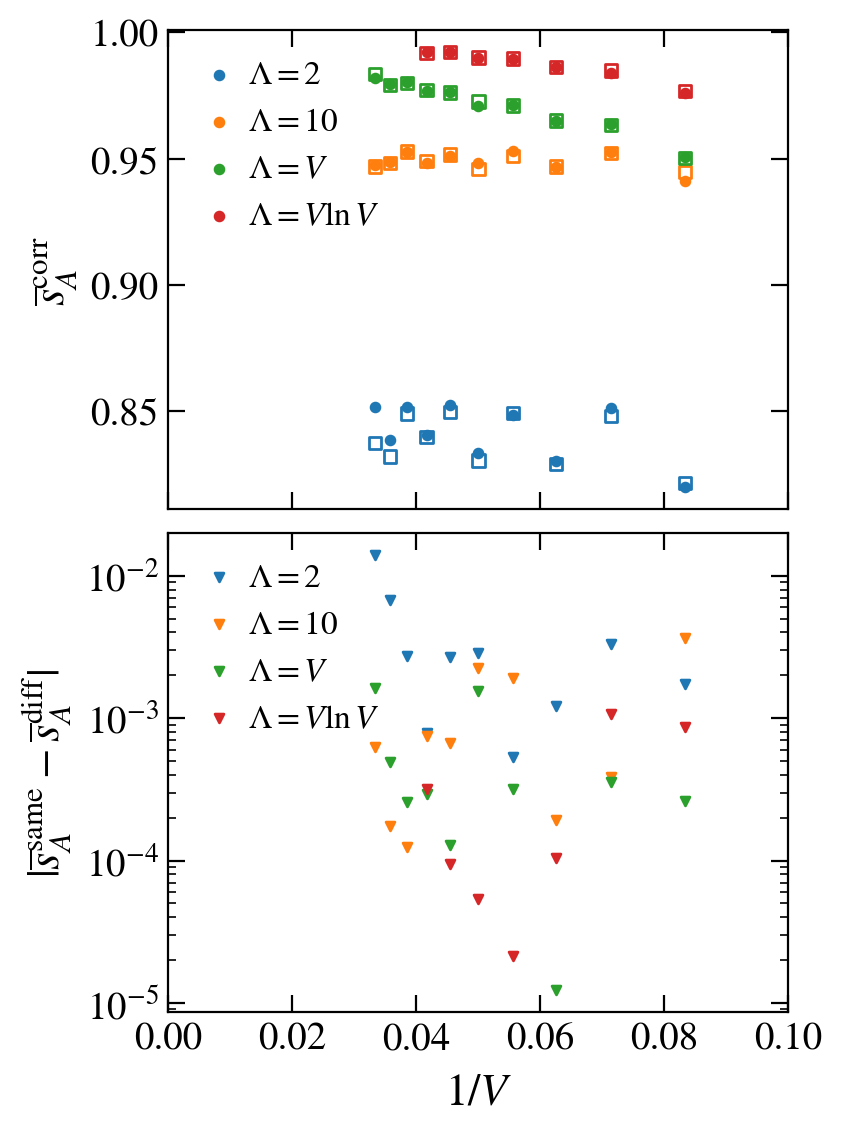

In [931]:
L = 100
w = 1
J = 1
g = 0.618



fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,6.5), dpi = 200, sharex = True)
# fig, axis_flu

op=1

ensemble = 'GOE'

def _get_prefix(_op):
    prefix = base_dir(model='SYK2', d=1, ensemble=ensemble) + 'Entropy/Degeneracy/'
    # prefix = base_dir(model='SYK2', d=1, ensemble=ensemble) + 'Entropy/NonGuassianity/'
    prefix += "RandomChoice/"
    if _op == 1:   prefix += "SameHamiltonian/"
    else:          prefix += "DifferentHamiltonian/"
    return prefix

prefix = _get_prefix(op)

colors_ls_cyc = itertools.cycle(colors_ls)
sizes = np.arange(12, 31, 2)

subsize_idx = -1


f = 1/4


names = [r"$\Lambda=1$",r"$\Lambda=2$",r"$\Lambda=4$",r"$\Lambda=10$", r"$\Lambda=\frac{V}{2}$", r"$\Lambda=V$", r"$\Lambda=2V$", r"$\Lambda=V\ln{V}$"]
indices = [1, 3, 5, 7]
colors_ls_cyc = itertools.cycle(colors_ls)
for ii in indices:
    nam = names[ii]
    sizes = np.arange(12, 31, 2) if ii < 6 else np.arange(12, 25, 2)
    col = next(colors_ls_cyc)

    prefix = _get_prefix(0)
    S_op0 = np.zeros(sizes.shape)
    for id_L, L in enumerate(sizes):
        V = L
        VA = int(f * V) if f > 0 else 1
        name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
        # print(name)
        if exists(name):
            with h5py.File(name, "r") as file:
                gams = np.array(file.get('Gammas'))
                subsystem = np.array(file.get('subsystem_sizes'))
                idx = np.argmin( np.abs(subsystem - VA) )
                # ent = np.array(file.get('entropy'))
                ent = np.array(file.get('entropy_corr_mat'))
                S_op0[id_L] = ent[idx, ii] / (VA * np.log(2))
        else:
            print(name)
    
    axis[0].scatter(1/sizes, S_op0, marker='o', s=10, color=col, facecolor=col, label=r"%s"%(nam))
    prefix = _get_prefix(1)
    S_op1 = np.zeros(sizes.shape)
    for id_L, L in enumerate(sizes):
        V = L
        VA = int(f * V) if f > 0 else 1
        name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
        # print(name)
        if exists(name):
            with h5py.File(name, "r") as file:
                gams = np.array(file.get('Gammas'))
                subsystem = np.array(file.get('subsystem_sizes'))
                idx = np.argmin( np.abs(subsystem - VA) )
                # ent = np.array(file.get('entropy'))
                ent = np.array(file.get('entropy_corr_mat'))
                S_op1[id_L] = ent[idx, ii] / (VA * np.log(2))
        else:
            print(name)
    axis[0].scatter(1/sizes, S_op1, marker='s', s=20, color=col, facecolor='None')

    axis[1].scatter(1/sizes, np.abs(S_op0 - S_op1), marker='v', s=10, color=col, facecolor=col, label=r"%s"%(nam))

fig_help.set_plot_elements(axis[0], ylabel=r"$\overline{s}^{\rm corr}_A$", font_size=14, set_legend=True, xlim=(0, 0.1), xscale='linear', yscale='linear')
axis[0].legend(loc = 'upper left', ncol=1, columnspacing=0.4, frameon=False, fontsize=12, handletextpad=0.25, handlelength = 1.25)

fig_help.set_plot_elements(axis[1], ylabel=r"$|\overline{s}_A^{\rm same} - \overline{s}_A^{\rm diff}|$", xlabel=r"$1/V$", font_size=14, set_legend=True, xlim=(0, 0.1), xscale='linear', yscale='log')
axis[1].legend(loc = 'upper left', ncol=1, columnspacing=0.4, frameon=False, fontsize=12, handletextpad=0.25, handlelength = 1.25)


# fig_help.set_plot_elements(ax_inset, ylabel=r"${\bar{S}_A} / \ln2$", xlabel=r"$W$", font_size=14, set_legend=False, xlim=(8.0, 25.0), ylim=(0.7, 1.0))

fig.subplots_adjust(wspace = 0.3, hspace=0.05)


Text(0.5, 1.0, '$L=20$')

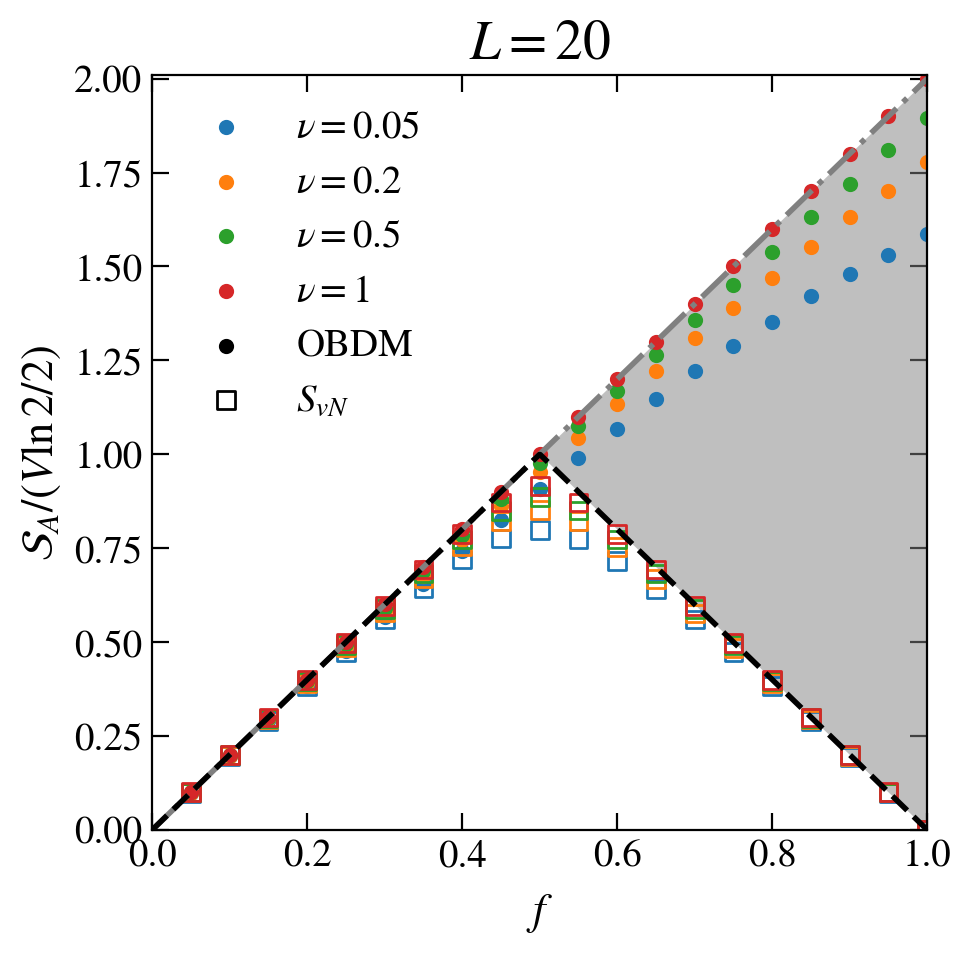

In [995]:
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)

ff = np.linspace(0, 1.0, 1000)
axis.plot(ff, 2*ff, ls='-.', color='gray', lw=2)
axis.plot(ff, 1 - 2*np.abs(0.5 - ff), ls='--', color='k', lw=2)
axis.fill_between(ff, 1 - 2*np.abs(0.5 - ff), 2*ff, color='gray', alpha=0.5, lw=0)

# ff = np.linspace(0., 0.5, 100)
# axis.plot(ff, 2 * ff * (1 - (1 + (1-ff)/ff * np.log(1-ff) ) / np.log(2)), ls=':', color='black')
# ff = np.linspace(.5, 1., 100)
# axis.plot(ff, 2 * (1-ff) * (1 - (1 + ff/(1-ff) * np.log(ff) ) / np.log(2)), ls=':', color='black')    

colors_ls_cyc = itertools.cycle(colors_ls)
L = 100
w = 1
J = 1
g = 0.618


L=20
V=L
op = 1
ensemble = 'GOE'

prefix = base_dir(model='SYK2', d=1, ensemble=ensemble) + 'Entropy/MixingExpMany2/'
# if op == 2:   prefix += "AllStates/"
# else:         prefix += "RandomChoice/"
prefix += "RandomChoice/"
if op == 1:   prefix += "SameHamiltonian/"
else:         prefix += "DifferentHamiltonian/"
    
name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
# print(name)

order = 3

if exists(name):
    with h5py.File(name, "r") as file:
        subsizes = np.array(file.get('subsystem_sizes'))
        Gammas = np.array(file.get('Gammas'))
        S = np.zeros((subsizes.size+1, Gammas.size))
        S[:-1, :] = np.array(file.get('entropy_corr_mat')) / (V//2*np.log(2))
        S[-1, :] = np.array(file.get('Non-Gaussianity')) / (V//2*np.log(2))
        # print(S)
        Sent = np.zeros((subsizes.size+1, Gammas.size))
        Sent[:-1,:] = np.array(file.get('entropy')) / (V//2*np.log(2))
        Sent[-1, :] = np.zeros((Gammas.size))

subsizes = np.array([*subsizes, V])
# print(S)

# Gammas = np.array([1, 2, 4, 10, V//2, V, 2*V, int(V*np.log(V))]) if V < 26 else np.array([1, 2, 4, 10, V//2, V])

zetas = np.arange(0.15, 0.99, 0.05);    indices = [5, 7, 9, 13, -1]
zetas = np.array([0.01, 0.02, 0.05, 0.1, 0.2, 0.25, 0.5, 0.75, 1.0]);   indices = [2, 4, 6, -1]

colors_ls_cyc = itertools.cycle(colors_ls)
for ii in indices:
    zeta = zetas[ii]
    nam = r"$\nu=%g$"%zeta
    gam = Gammas[ii]
    col = next(colors_ls_cyc)

    ff = np.linspace(0, 1, 1000)
    # axis.plot(ff, 2 * ff * s_QCQ(ff, gam), ls='--', color=col, lw=0.75)
    # axis.fill_between(ff, 2*ff*QC_lower_bound(f=ff, x=gam, n=order), 2*ff*QC_upper_bound(f=ff, x=gam, n=order), alpha=0.5, color=col)
    
    # print(2 * ff * ( 1 - (s_QCQ(ff, gam)) / (np.log(2)) ))
    
    # ff = np.linspace(0.5, 1.0, 100)
    # axis.plot(ff, 2*(1-ff)*s_QCQ(1-ff, gam), ls='-', color=col, lw=0.75)

    axis.scatter(subsizes / L, S[:, ii], marker = 'o', color=col, s=20, label=nam)
    axis.scatter(subsizes / L, Sent[:, ii], marker = 's', color=col, s=40, facecolor='None')
    # axis.scatter(1 - subsizes[::5] / L, S[::5,gam - 1], color=col, s=10, facecolor='None')
    # axis.axvline(x=np.sqrt(gam), ls=':', color=col)

axis.scatter(np.nan, np.nan, marker = 'o', color='k', s=20, label=r"OBDM")
axis.scatter(np.nan, np.nan, marker = 's', color='k', s=40, label=r"$S_{vN}$", facecolor='None')
fig_help.set_plot_elements(axis, ylabel=r"${\mathcal{S}_A} / (V\ln2/2)$", xlabel=r"$f$", font_size=14, set_legend=True, xlim=(0,1), ylim=(0,2.01), xscale='linear', yscale='linear')
axis.set_title(r"$L=%d$"%L, fontsize = 20)


[ 15.35567064  25.95487321  44.03838853  74.94212127 127.83195194] [ 6.  7.  8.  9. 10.]
[ 30.39736831  58.58327406 113.44602241 220.49943311 429.83252553] [ 6.  7.  8.  9. 10.]
[  60.17321038  132.22950358  292.24502595  648.7673311  1445.30375389] [ 6.  7.  8.  9. 10.]
[  235.79662082   673.65544331  1939.37966473  5616.32153975
 16341.00793568] [ 6.  7.  8.  9. 10.]
[   656.73229393   2284.38823717   8018.61975408  28344.8528535
 100755.4677565 ] [ 6.  7.  8.  9. 10.]


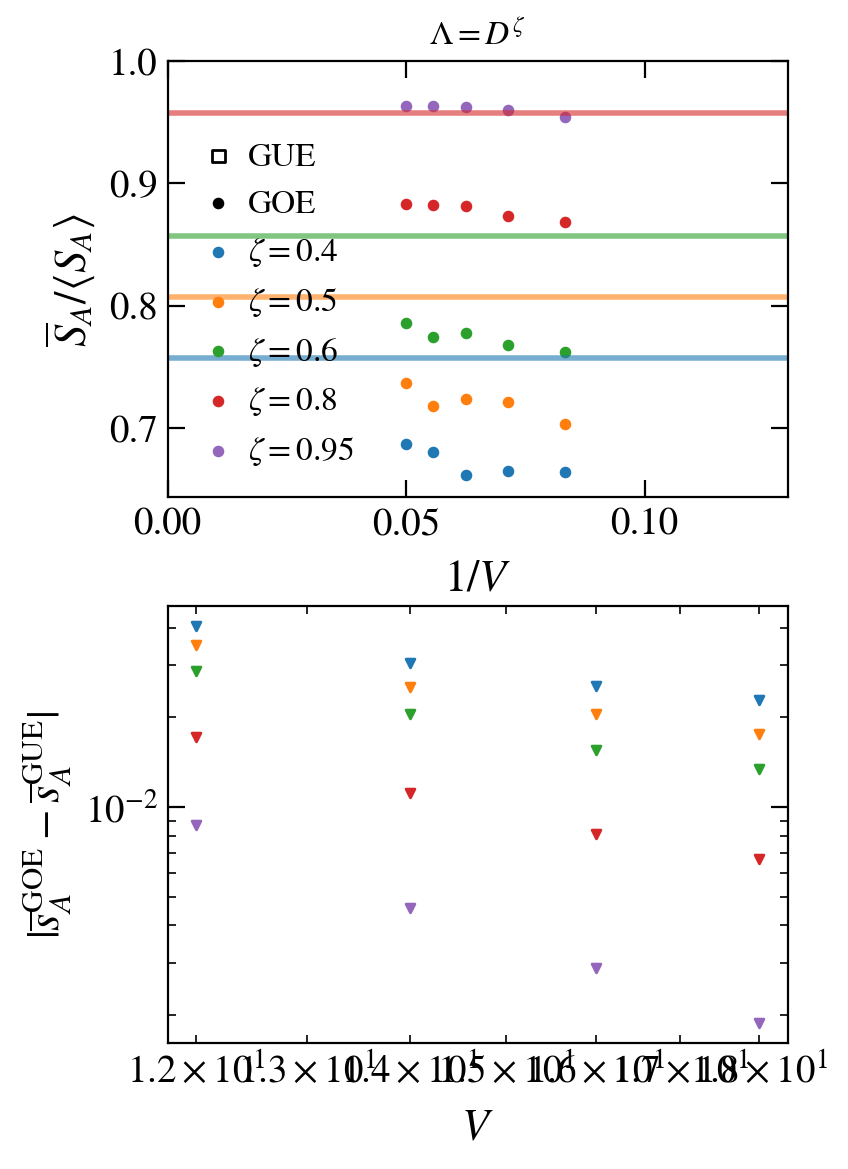

In [1042]:
import entropy as ent
L = 100
w = 1
J = 1
g = 0.618



fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,6.5), dpi = 200, sharex = False)
# fig, axis_flu

op=1

ensemble = 'GOE'

def _get_prefix(_op, ens = 'GOE'):
    prefix = base_dir(model='SYK2', d=1, ensemble=ens) + 'Entropy/MixingExpMany/'
    prefix += "RandomChoice/"
    if _op == 1:   prefix += "SameHamiltonian/"
    else:          prefix += "DifferentHamiltonian/"
    return prefix

prefix = _get_prefix(op)

colors_ls_cyc = itertools.cycle(colors_ls)
sizes = np.arange(12, 21, 2)

subsize_idx = -1


f = 1/2

zetas = np.arange(0.15, 0.99, 0.05)
indices = [5, 7, 9, 13, -1]
colors_ls_cyc = itertools.cycle(colors_ls)

axis[0].scatter(np.nan, np.nan, marker='s', s=20, color='k', facecolor='None', label=r"GUE")
axis[0].scatter(np.nan, np.nan, marker='o', s=10, color='k', facecolor='k', label=r"GOE")
for ii in indices:
    zeta = zetas[ii]
    print( binom(sizes, sizes//2)**zeta, sizes/2 )
    col = next(colors_ls_cyc)

    prefix = _get_prefix(1, 'GOE')
    S_GOE = np.zeros(sizes.shape)
    for id_L, L in enumerate(sizes):
        V = L
        VA = int(f * V) if f > 0 else 1
        name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
        # print(name)
        if exists(name):
            with h5py.File(name, "r") as file:
                gams = np.array(file.get('Gammas'))
                subsystem = np.array(file.get('subsystem_sizes'))
                idx = np.argmin( np.abs(subsystem - VA) )
                S_GOE[id_L] = np.array(file.get('entropy'))[idx, ii] / ent.page(VA, V - VA)
                # S_GOE[id_L] = np.array(file.get('entropy'))[idx, ii] / (L//2 * np.log(2))
        else:
            print(name)
    axis[0].scatter(1/sizes, S_GOE, marker='o', s=10, color=col, facecolor=col, label=r"$\zeta=%g$"%(zeta))
    
    prefix = _get_prefix(1, 'GUE')
    S_GUE = np.zeros(sizes.shape)
    for id_L, L in enumerate(sizes):
        V = L
        VA = int(f * V) if f > 0 else 1
        name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
        # print(name)
        if exists(name):
            with h5py.File(name, "r") as file:
                gams = np.array(file.get('Gammas'))
                subsystem = np.array(file.get('subsystem_sizes'))
                idx = np.argmin( np.abs(subsystem - VA) )
                S_GUE[id_L] = np.array(file.get('entropy'))[idx, ii] / ent.page(VA, V - VA)
                # S_GUE[id_L] = np.array(file.get('entropy'))[idx, ii] / (L//2 * np.log(2))
                # print(ent.page(L//2, L//2))
        else:
            print(name)
    # axis[0].scatter(1/sizes, S_GUE, marker='s', s=20, color=col, facecolor='None')

    axis[1].scatter(sizes[:-1], np.abs(S_GOE - S_GUE)[:-1], marker='v', s=10, color=col, facecolor=col, label=r"$\zeta=%g$"%(zeta))
    axis[0].axhline(y=0.5573+zeta/2, color=col, lw=2, alpha=0.6)


fig_help.set_plot_elements(axis[0], ylabel=r"$\overline{S}_A/\langle S_A\rangle$", xlabel=r"$1/V$", font_size=14, set_legend=True, xlim = (0, 0.13), xscale='linear', yscale='linear')
axis[0].legend(loc = 'lower left', ncol=1, columnspacing=0.4, frameon=False, fontsize=12, handletextpad=0.25, handlelength = 1.25)
axis[0].set_ylim(None, 1)
axis[0].set_title(r"$\Lambda=D^\zeta$")
fig_help.set_plot_elements(axis[1], ylabel=r"$|\overline{s}_A^{\rm GOE} - \overline{s}_A^{\rm GUE}|$", xlabel=r"$V$", font_size=14, set_legend=False, xscale='log', yscale='log')
# axis[1].legend(loc = 'upper left', ncol=1, columnspacing=0.4, frameon=False, fontsize=12, handletextpad=0.25, handlelength = 1.25)


# fig_help.set_plot_elements(ax_inset, ylabel=r"${\bar{S}_A} / \ln2$", xlabel=r"$W$", font_size=14, set_legend=False, xlim=(8.0, 25.0), ylim=(0.7, 1.0))

fig.subplots_adjust(wspace = 0.3, hspace=0.25)


[1.31846932 1.40696599 1.5023716  1.60501438 1.71530261 1.83370694] [ 5.  6.  7.  8.  9. 10.]
[ 3.02190014  3.91863122  5.09459255  6.63614259  8.65691176 11.30627931] [ 5.  6.  7.  8.  9. 10.]
[ 15.87450787  30.39736831  58.58327406 113.44602241 220.49943311
 429.83252553] [ 5.  6.  7.  8.  9. 10.]
[   252.    924.   3432.  12870.  48620. 184756.] [ 5.  6.  7.  8.  9. 10.]


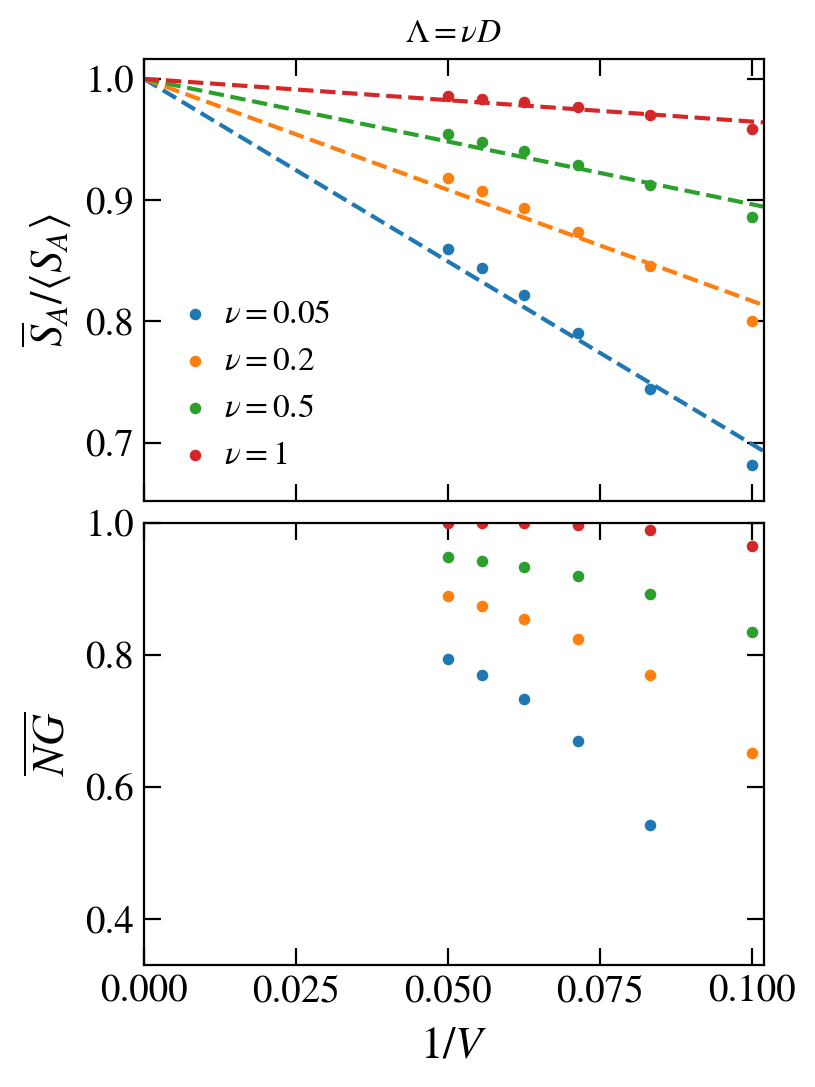

In [985]:
import entropy as ent
L = 100
w = 1
J = 1
g = 0.618



fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,6), dpi = 200, sharex = True)
# fig, axis_flu

op=1

ensemble = 'GOE'

def _get_prefix(_op, ens = 'GOE'):
    prefix = base_dir(model='SYK2', d=1, ensemble=ens) + 'Entropy/MixingExpMany2/'
    prefix += "RandomChoice/"
    if _op == 1:   prefix += "SameHamiltonian/"
    else:          prefix += "DifferentHamiltonian/"
    return prefix

prefix = _get_prefix(op)

colors_ls_cyc = itertools.cycle(colors_ls)
sizes = np.arange(10, 21, 2)

subsize_idx = -1


f = 1/2

zetas = np.array([0.01, 0.02, 0.05, 0.1, 0.2, 0.25, 0.5, 0.75, 1.0])
indices = [2, 4, 6, -1]
colors_ls_cyc = itertools.cycle(colors_ls)

# axis.scatter(np.nan, np.nan, marker='s', s=20, color='k', facecolor='None', label=r"GUE")
# axis.scatter(np.nan, np.nan, marker='o', s=10, color='k', facecolor='k', label=r"GOE")
for ii in indices:
    zeta = zetas[ii]
    print( binom(sizes, sizes//2)**zeta, sizes/2 )
    col = next(colors_ls_cyc)

    prefix = _get_prefix(1, 'GOE')
    S_GOE = np.zeros(sizes.shape)
    Sc_GOE = np.zeros(sizes.shape)
    NG_GOE = np.zeros(sizes.shape)
    for id_L, L in enumerate(sizes):
        V = L
        VA = int(f * V) if f > 0 else 1
        name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
        # print(name)
        if exists(name):
            with h5py.File(name, "r") as file:
                gams = np.array(file.get('Gammas'))
                subsystem = np.array(file.get('subsystem_sizes'))
                idx = np.argmin( np.abs(subsystem - VA) )
                S_GOE[id_L] = np.array(file.get('entropy'))[idx, ii] / ent.page(VA, V - VA)
                Sc_GOE[id_L] = np.array(file.get('entropy_corr_mat'))[idx, ii] / ent.page(VA, V - VA)
                NG_GOE[id_L] = np.array(file.get('Non-Gaussianity'))[ii] / (V * np.log(2))
                # S_GOE[id_L] = np.array(file.get('entropy'))[idx, ii] / (L//2 * np.log(2))
        else:
            print(name)
    axis[0].scatter(1/sizes, S_GOE, marker='o', s=10, color=col, facecolor=col, label=r"$\nu=%g$"%(zeta))
    # axis[0].scatter(1/sizes, Sc_GOE, marker='s', s=20, color=col, facecolor='None')
    axis[1].scatter(1/sizes, NG_GOE, marker='o', s=10, color=col, facecolor=col, label=r"$\nu=%g$"%(zeta))

    def lin_fitt(x, a, b):
        return 1 - a * x
        # return 1 - np.exp(b * x)
    pars, pconv= fit(lin_fitt,
                xdata = 1/sizes,
                ydata = S_GOE,
                maxfev = 20000)
    z = np.linspace(0, 0.11, 10000)
    axis[0].plot(z, lin_fitt(z, *pars), ls='--', color=col)
    
    # prefix = _get_prefix(1, 'GUE')
    # S_GUE = np.zeros(sizes.shape)
    # for id_L, L in enumerate(sizes):
    #     V = L
    #     VA = int(f * V) if f > 0 else 1
    #     name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
    #     # print(name)
    #     if exists(name):
    #         with h5py.File(name, "r") as file:
    #             gams = np.array(file.get('Gammas'))
    #             subsystem = np.array(file.get('subsystem_sizes'))
    #             idx = np.argmin( np.abs(subsystem - VA) )
    #             S_GUE[id_L] = np.array(file.get('entropy'))[idx, ii] / ent.page(VA, V - VA)
    #             # S_GUE[id_L] = np.array(file.get('entropy'))[idx, ii] / (L//2 * np.log(2))
    #             # print(ent.page(L//2, L//2))
    #     else:
    #         print(name)
    # axis[0].scatter(1/sizes, S_GUE, marker='s', s=20, color=col, facecolor='None')
    # z = np.linspace(0, 0.11, 1000)
    # axis.plot(z, 1 - 1/2 * z, ls='--', color=col)

fig_help.set_plot_elements(axis[0], ylabel=r"$\overline{S}_A/\langle S_A\rangle$", xlabel=r"", font_size=14, set_legend=True, xlim = (0, 0.102), xscale='linear', yscale='linear')
axis[0].legend(loc = 'lower left', ncol=1, columnspacing=0.4, frameon=False, fontsize=12, handletextpad=0.25, handlelength = 1.25)
# axis[0].set_ylim(0.65, 1.19)
axis[0].set_title(r"$\Lambda=\nu D$")

fig_help.set_plot_elements(axis[1], ylabel=r"$\overline{NG}$", xlabel=r"$1/V$", font_size=14, set_legend=False, xscale='linear', yscale='linear')
axis[1].set_ylim(0.33, 1)
# fig_help.set_plot_elements(ax_inset, ylabel=r"${\bar{S}_A} / \ln2$", xlabel=r"$W$", font_size=14, set_legend=False, xlim=(8.0, 25.0), ylim=(0.7, 1.0))

fig.subplots_adjust(wspace = 0.05, hspace=0.05)


[  5.4706536    9.13188043  15.35567064  25.95487321  44.03838853
  74.94212127 127.83195194] [ 4.  5.  6.  7.  8.  9. 10.]
[  8.36660027  15.87450787  30.39736831  58.58327406 113.44602241
 220.49943311 429.83252553] [ 4.  5.  6.  7.  8.  9. 10.]
[  12.79554605   27.59563071   60.17321038  132.22950358  292.24502595
  648.7673311  1445.30375389] [ 4.  5.  6.  7.  8.  9. 10.]
[   29.92805078    83.39124018   235.79662082   673.65544331
  1939.37966473  5616.32153975 16341.00793568] [ 4.  5.  6.  7.  8.  9. 10.]
[5.66034807e+01 1.91130728e+02 6.56732294e+02 2.28438824e+03
 8.01861975e+03 2.83448529e+04 1.00755468e+05] [ 4.  5.  6.  7.  8.  9. 10.]


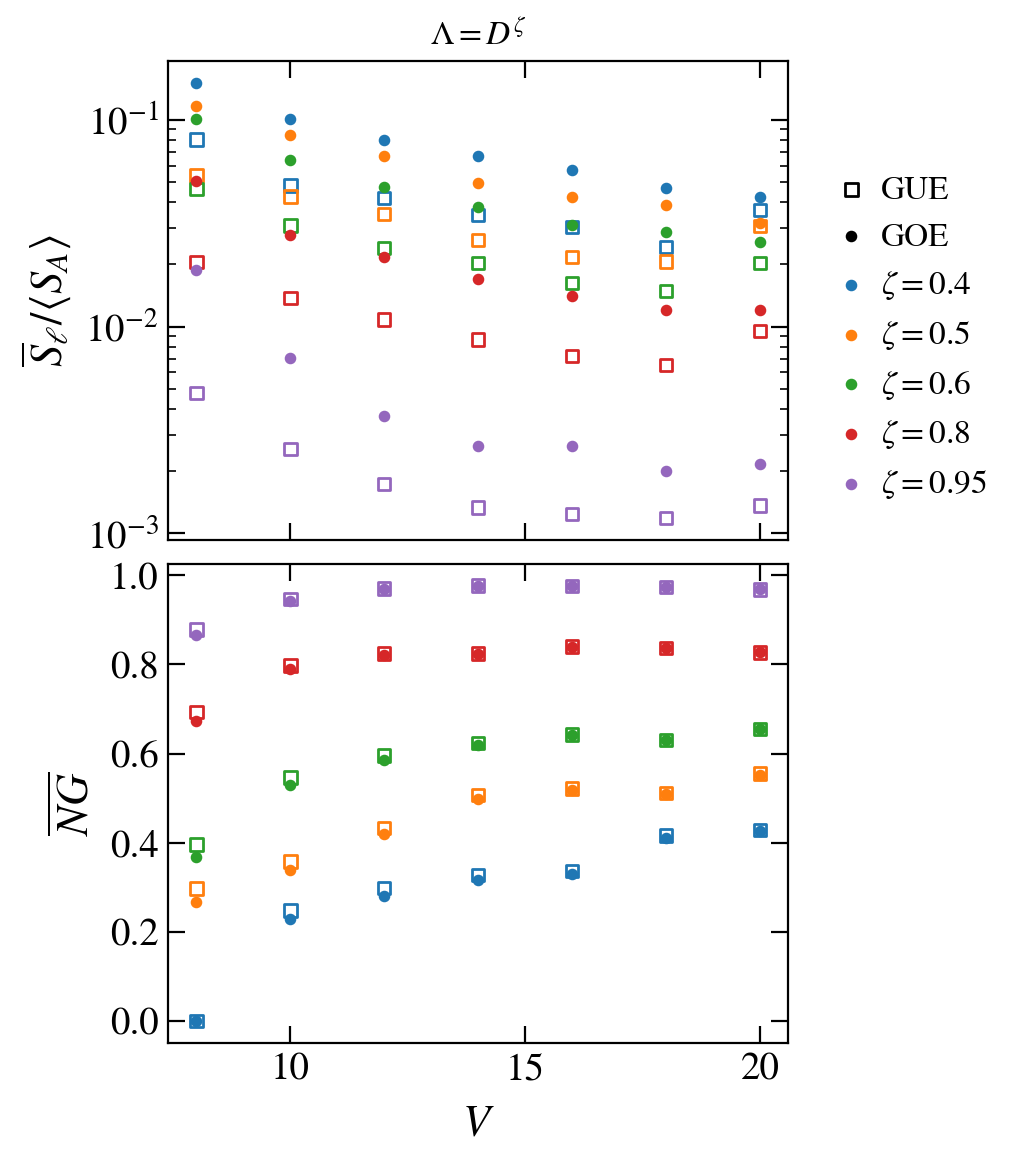

In [988]:
import entropy as ent
L = 100
w = 1
J = 1
g = 0.618



fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,6.5), dpi = 200, sharex = True)
# fig, axis_flu

op=1

ensemble = 'GOE'

def _get_prefix(_op, ens = 'GOE'):
    prefix = base_dir(model='SYK2', d=1, ensemble=ens) + 'Entropy/MixingExpMany/'
    prefix += "RandomChoice/"
    if _op == 1:   prefix += "SameHamiltonian/"
    else:          prefix += "DifferentHamiltonian/"
    return prefix

prefix = _get_prefix(op)

colors_ls_cyc = itertools.cycle(colors_ls)
sizes = np.arange(8, 21, 2)

subsize_idx = -1


f = 0

zetas = np.arange(0.15, 0.99, 0.05)
indices = [5, 7, 9, 13, -1]
colors_ls_cyc = itertools.cycle(colors_ls)

axis[0].scatter(np.nan, np.nan, marker='s', s=20, color='k', facecolor='None', label=r"GUE")
axis[0].scatter(np.nan, np.nan, marker='o', s=10, color='k', facecolor='k', label=r"GOE")
for ii in indices:
    zeta = zetas[ii]
    print( binom(sizes, sizes//2)**zeta, sizes/2 )
    col = next(colors_ls_cyc)

    prefix = _get_prefix(1, 'GOE')
    S_GOE = np.zeros(sizes.shape)
    NG_GOE = np.zeros(sizes.shape)
    for id_L, L in enumerate(sizes):
        V = L
        VA = int(f * V) if f > 0 else 1
        name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
        # print(name)
        if exists(name):
            with h5py.File(name, "r") as file:
                gams = np.array(file.get('Gammas'))
                subsystem = np.array(file.get('subsystem_sizes'))
                idx = np.argmin( np.abs(subsystem - VA) )
                S_GOE[id_L] = 1-np.array(file.get('entropy'))[idx, ii] / ent.page(VA, V - VA)
                NG_GOE[id_L] = np.array(file.get('Non-Gaussianity'))[ii] / (V * np.log(2))
                # S_GOE[id_L] = np.array(file.get('entropy'))[idx, ii] / (L//2 * np.log(2))
        else:
            print(name)
    axis[0].scatter(sizes, S_GOE, marker='o', s=10, color=col, facecolor=col, label=r"$\zeta=%g$"%(zeta))
    axis[1].scatter(sizes, NG_GOE, marker='o', s=10, color=col, facecolor=col, label=r"$\zeta=%g$"%(zeta))
    
    prefix = _get_prefix(1, 'GUE')
    S_GUE = np.zeros(sizes.shape)
    NG_GUE = np.zeros(sizes.shape)
    for id_L, L in enumerate(sizes):
        V = L
        VA = int(f * V) if f > 0 else 1
        name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
        # print(name)
        if exists(name):
            with h5py.File(name, "r") as file:
                gams = np.array(file.get('Gammas'))
                subsystem = np.array(file.get('subsystem_sizes'))
                idx = np.argmin( np.abs(subsystem - VA) )
                S_GUE[id_L] = 1-np.array(file.get('entropy'))[idx, ii] / ent.page(VA, V - VA)
                NG_GUE[id_L] = np.array(file.get('Non-Gaussianity'))[ii] / (V * np.log(2))
                # S_GUE[id_L] = np.array(file.get('entropy'))[idx, ii] / (L//2 * np.log(2))
                # print(ent.page(L//2, L//2))
        else:
            print(name)
    axis[0].scatter(sizes, S_GUE, marker='s', s=20, color=col, facecolor='None')
    axis[1].scatter(sizes, NG_GUE, marker='s', s=20, color=col, facecolor='None')

    # axis[1].scatter(sizes[:-1], np.abs(S_GOE - S_GUE)[:-1], marker='v', s=10, color=col, facecolor=col, label=r"$\zeta=%g$"%(zeta))
    # axis[0].axhline(y=zeta**0.5, color=col, lw=2, alpha=0.6)


fig_help.set_plot_elements(axis[0], ylabel=r"$\overline{S}_\ell/\langle S_A\rangle$", xlabel=r"", font_size=14, set_legend=True, xscale='linear', yscale='log')
axis[0].legend(loc = 'lower left', ncol=1, columnspacing=0.4, frameon=False, fontsize=12, handletextpad=0.25, handlelength = 1.25, bbox_to_anchor=(1.02, 0.02))
# axis[0].set_ylim(None, 1)
axis[0].set_title(r"$\Lambda=D^\zeta$")
fig_help.set_plot_elements(axis[1], ylabel=r"$\overline{NG}$", xlabel=r"$V$", font_size=14, set_legend=False, xscale='linear', yscale='linear')
# axis[1].legend(loc = 'upper left', ncol=1, columnspacing=0.4, frameon=False, fontsize=12, handletextpad=0.25, handlelength = 1.25)


# fig_help.set_plot_elements(ax_inset, ylabel=r"${\bar{S}_A} / \ln2$", xlabel=r"$W$", font_size=14, set_legend=False, xlim=(8.0, 25.0), ylim=(0.7, 1.0))

fig.subplots_adjust(wspace = 0.1, hspace=0.05)


No handles with labels found to put in legend.
No handles with labels found to put in legend.


[ 2  3  5  8 12 19 29 45 70] [1.69202375 2.7918305  3.67206001 4.18775216 4.48332908 4.74530811
 4.86436858 4.95512048 5.02093022]
[  3   5   9  15  27  47  83 144 252] [3.69614641 4.79656821 5.62293435 6.05217078 6.38763925 6.54797532
 6.63199152 6.68299441 6.71233793]


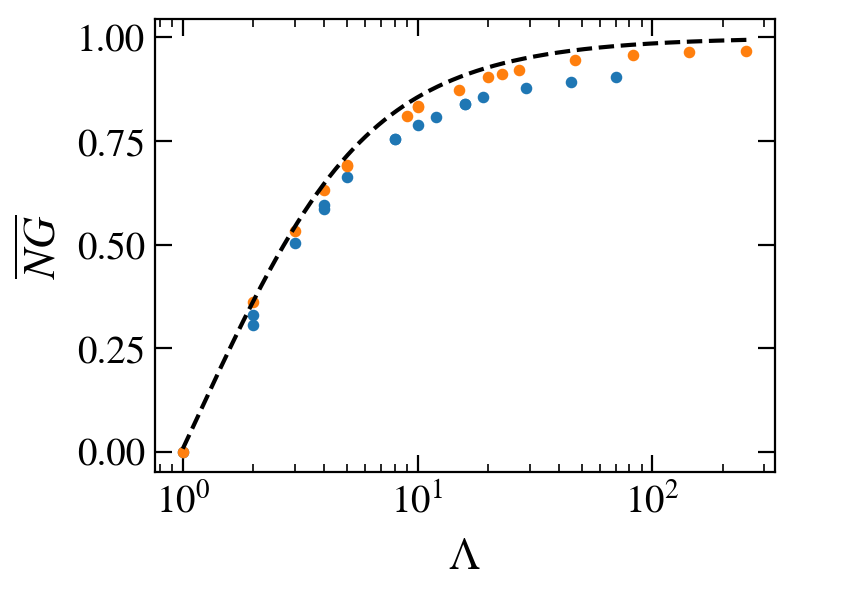

In [1037]:
import entropy as ent
L = 100
w = 1
J = 1
g = 0.618



fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex = True)
# fig, axis_flu

op=1

ensemble = 'GUE'

def _get_prefix(_op, ens = 'GOE', _base = 'Entropy/MixingExpMany/'):
    prefix = base_dir(model='SYK2', d=1, ensemble=ens) + _base + "RandomChoice/"
    if _op == 1:   prefix += "SameHamiltonian/"
    else:          prefix += "DifferentHamiltonian/"
    return prefix
prefix = _get_prefix(op)

colors_ls_cyc = itertools.cycle(colors_ls)

L = 10


for L in [8, 10]:
    Gams = []
    NG_GOE = []
    prefix = _get_prefix(1, ensemble, 'Entropy/Degeneracy/')
    name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
    if exists(name):
        with h5py.File(name, "r") as file:
            Gams = [*Gams, *np.array(file.get('Gammas'))]
            NG_GOE = [*NG_GOE, *np.array(file.get('Non-Gaussianity')) / (L * np.log(2))]
    else:
        print(name)
        
    prefix = _get_prefix(1, ensemble, 'Entropy/MixingExpMany/')
    name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
    if exists(name):
        with h5py.File(name, "r") as file:
            Gams = [*Gams, *np.array(file.get('Gammas'))]
            print(np.array(file.get('Gammas')), np.array(file.get('Non-Gaussianity')))
            NG_GOE = [*NG_GOE, *np.array(file.get('Non-Gaussianity')) / (L * np.log(2))]
    else:
        print(name)
        
    # prefix = _get_prefix(1, ensemble, 'Entropy/MixingExpMany2/')
    # name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
    # if exists(name):
    #     with h5py.File(name, "r") as file:
    #         Gams = [*Gams, *np.array(file.get('Gammas'))]
    #         NG_GOE = [*NG_GOE, *np.array(file.get('Non-Gaussianity')) / (L * np.log(2))]
    # else:
    #     print(name)
            
    Gams = np.array(Gams)
    NG_GOE = np.array(NG_GOE)

    indices = np.argsort(Gams)
    Gams = Gams[indices]
    NG_GOE = NG_GOE[indices]

    axis.scatter(Gams, NG_GOE, marker='o', s=10, color = next(colors_ls_cyc))

x = np.linspace(1, max(Gams), 10000)
axis.plot(x, NonGaussianity(x=x, n=50, ens=(ensemble == 'GUE')), ls='--', color='k')


fig_help.set_plot_elements(axis, ylabel=r"$\overline{NG}$", xlabel=r"$\Lambda$", font_size=14, set_legend=True, xscale='log', yscale='linear')
axis.legend(loc = 'lower left', ncol=1, columnspacing=0.4, frameon=False, fontsize=12, handletextpad=0.25, handlelength = 1.25, bbox_to_anchor=(1.02, 0.02))

fig.subplots_adjust(wspace = 0.1, hspace=0.05)


In [1035]:
J=1
w=1
g=1
op=1

DIM = 1
modello = 'SYK2'
ensemble = 'GUE'
prefix = base_dir(model=modello, d=DIM, ensemble=ensemble) + 'Entropy/MixingExpMany/'
# if op == 2:   prefix += "AllStates/"
# elif op == 0:   prefix += "E=0,Q=0/"
# else:         prefix += "RandomChoice/"
prefix += "RandomChoice/"
if op == 1:   prefix += "SameHamiltonian/"
else:         prefix += "DifferentHamiltonian/"

for L in np.arange(8, 11, 2):
    V = int(L**DIM)
    # Gammas = np.array([1, 2, 4, 10, V//2, V, 2*V, int(V*np.log(V))]) if V < 26 else np.array([1, 2, 4, 10, V//2, V])
    Gammas = np.zeros((9))
    
    subsystem = np.arange(1, V, 1)
    
    entropy = np.zeros((subsystem.size, Gammas.size))
    
    nongauss = np.zeros((Gammas.size))
    entropy_corr = np.zeros((subsystem.size, Gammas.size))
    entropy_site_corr = np.zeros((subsystem.size, Gammas.size))
    
    _compare_nongauss = np.zeros((Gammas.size))
    _compare_entropy_corr = np.zeros((subsystem.size, Gammas.size))
    _compare_entropy_site_corr = np.zeros((subsystem.size, Gammas.size))
#            part_ratio = np.zeros((Gammas.size, qs.size))
    counter = 0
    for jobid in np.arange(0, 1000, 1):
        name =  prefix + 'realisation=%d/'%jobid + info(L=L, J=J, w=w, g=g, model = modello, ext=f'.hdf5')
        # print(name)
        if exists(name):
            with h5py.File(name, "r") as file:
                Gammas = np.array(file.get('Gammas'))[0]
                subsystem = np.array(file.get('subsystem_sizes'))[0]
                entropy += np.array(file.get('entropy'))
                
                entropy_corr += np.array(file.get('entropy_corr_mat'))
                entropy_site_corr += np.array(file.get('entropy_single_site_corr_mat'))
                nongauss += np.array(file.get('Non-Gaussianity'))[0]
                
                _compare_nongauss += np.array(file.get('COMPARISON/Non-Gaussianity'))[0]
                _compare_entropy_corr += np.array(file.get('COMPARISON/entropy'))
                _compare_entropy_site_corr += np.array(file.get('COMPARISON/single_site_entropy'))
#                        part_ratio += np.transpose( np.array(file.get('participation_ratio')) )
#                        qs = np.array(file.get('qs'))[0]
                counter += 1
        # else:
        #     print(name)   
    print(V, w, counter, flush=True)
    if counter > 0:
#                entropy = np.array(entropy) / counter
#                part_ratio = np.array(part_ratio) / counter / 50

        entropy = np.array(entropy) / counter
        entropy_corr = np.array(entropy_corr) / counter
        entropy_site_corr = np.array(entropy_site_corr) / counter
        
        _compare_nongauss = np.array(_compare_nongauss) / counter
        _compare_entropy_corr = np.array(_compare_entropy_corr) / counter
        _compare_entropy_site_corr = np.array(_compare_entropy_site_corr) / counter
        
        nongauss = np.array(nongauss) / counter
        name = prefix + info(L=L, J=J, w=w, g=g, model=modello, ext='.hdf5')

        hf = h5py.File(name, 'w')
        hf.create_dataset('Gammas',                Gammas.shape,              data = Gammas)
        hf.create_dataset('subsystem_sizes',       subsystem.shape,           data = subsystem)
        
        hf.create_dataset('entropy',               entropy.shape,             data = entropy)
        hf.create_dataset('entropy_corr_mat',      entropy_corr.shape,        data = entropy_corr)
        hf.create_dataset('Non-Gaussianity',       nongauss.shape,            data = nongauss)
        
        hf.create_dataset('COMPARISON/entropy',               _compare_entropy_corr.shape,        data = _compare_entropy_corr)
        hf.create_dataset('COMPARISON/Non-Gaussianity',       _compare_nongauss.shape,            data = _compare_nongauss)
        hf.create_dataset('COMPARISON/single_site_entropy',   _compare_entropy_site_corr.shape,   data = _compare_entropy_site_corr)
#                hf.create_dataset('qs',                     qs.shape,                   data = qs)
#                hf.create_dataset('participation_ratio',    part_ratio.shape,           data = part_ratio)
        hf['realisations'] = counter

        hf.close()

8 1 500
10 1 500
